In [1]:
import os
import typing
import pandas as pd
import numpy as np
import spacy
from pprint import pprint
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import json

with open('/home/mkeber/syn-bioner/data/clustering/grid_search_embeddings_train.jsonl', 'r') as file:
    grid_search_emb = [json.loads(line) for line in file] 


In [ ]:
with open('/home/mkeber/syn-bioner/data/clustering/grid_search_embeddings_extended.jsonl', 'r') as file:
    grid_search_emb.extend([json.loads(line) for line in file])

In [ ]:
len(grid_search_emb)

44

In [ ]:
import utils.kmeans_params as kp
from tqdm import tqdm

In [20]:
# features_data
kmeans_results = []
for sample in tqdm(grid_search_emb):
    emb_arr = np.array(sample['embedding'])
    for k in tqdm(range(5, 16)):
        kmeans_results.append(kp.evaluate_k(emb_arr, k))
        kmeans_results[-1]['hyperparameters'] = sample['hyperparameters']
        kmeans_results[-1]['k'] = k

KeyboardInterrupt: 

In [24]:
smax = max([k['silhouette'] for k in kmeans_results])
# max(for k in kmeans_results, key=kmeans_results.silhouette)
for k in kmeans_results:
    if k['silhouette'] == smax:
        print(k['hyperparameters'])
        print(k['k'])

{'wl_iterations': 1, 'dimensions': 16, 'workers': 24, 'learning_rate': 0.04, 'min_count': 2, 'epochs': 20}
6


In [34]:
for line in kmeans_results:
    # line['centroids'] = line['centroids'].tolist()
    if type(line['labels']) != list:
        line['labels'] = line['labels'].tolist()
    # line['inertia'] = line['inertia'].tolist()
    
    
    # print(type(line['centroids']))

In [35]:
len(kmeans_results)
output_path_kmeans = "/home/mkeber/syn-bioner/data/clustering/grid_search_embeddings_train_kmeans.jsonl"

with open(output_path_kmeans, 'a') as file:
    for line in kmeans_results:
        file.write(json.dumps(line) + "\n")

In [25]:
imin = min([k['inertia'] for k in kmeans_results])
for k in kmeans_results:
    if k['inertia'] == imin:
        print(k['hyperparameters'])
        print(k['k'])
        

{'wl_iterations': 1, 'dimensions': 16, 'workers': 24, 'learning_rate': 0.04, 'min_count': 2, 'epochs': 20}
15


In [39]:
with open('/home/mkeber/syn-bioner/data/ncbi/trf/syntax_features/syntax_features_sent_tree_head.json', 'r') as f:
    features_data = json.load(f)

In [40]:
len(features_data)

14008

In [41]:
import networkx as nx

def build_dependency_graphs(data, use_root=True):
    """
    Build directed dependency graphs encoding only syntactic structure (POS + dependency).
    Graphs are directed from parent -> child.

    Args:
        data (list[dict]): list of dependency-parsed sentence dicts.
        use_root (bool): if True, add an explicit root node.

    Returns:
        dict[int, nx.DiGraph]: mapping from sentence ID to NetworkX graph.
    """
    graphs = {}

    for entry in data:
        sent_id = entry["id"]
        sentence = entry["sentence"]
        pos_tags = entry["pos"]
        dep_labels = entry["dep"]
        parents = entry["parents"]
        G = nx.DiGraph(id=sent_id, sentence=sentence)
        n = len(pos_tags)
        for i in range(0, n):
            node_label = f"{pos_tags[i]}"
            G.add_node(i, feature=node_label, is_root=False)

        # --- Add edges (parent -> child) ---
        for child_idx, parent_idx in enumerate(parents):
            G.add_edge(parent_idx, child_idx, feature=f'{dep_labels[child_idx]}')

        graphs[sent_id] = G
    return graphs

# Example usage:
graphs = build_dependency_graphs(features_data, use_root=True)

# Inspect one example
example_id = 1
G = graphs[example_id]

print(f"Sentence {example_id}: {G.graph['sentence']}")
print("Nodes:")
for node, attrs in G.nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges:")
for u, v, attrs in G.edges(data=True):
    print(f"  {u} -> {v}: {attrs}")
print("\n"
      "-----------------------------------\n"
      )
pprint(features_data[0])

Sentence 1: A common human skin tumour is caused by activating mutations in beta-catenin.
Nodes:
  0: {'feature': 'DET', 'is_root': False}
  1: {'feature': 'ADJ', 'is_root': False}
  2: {'feature': 'ADJ', 'is_root': False}
  3: {'feature': 'NOUN', 'is_root': False}
  4: {'feature': 'NOUN', 'is_root': False}
  5: {'feature': 'AUX', 'is_root': False}
  6: {'feature': 'VERB', 'is_root': False}
  7: {'feature': 'ADP', 'is_root': False}
  8: {'feature': 'VERB', 'is_root': False}
  9: {'feature': 'NOUN', 'is_root': False}
  10: {'feature': 'ADP', 'is_root': False}
  11: {'feature': 'NOUN', 'is_root': False}
  12: {'feature': 'PUNCT', 'is_root': False}
  13: {'feature': 'NOUN', 'is_root': False}
  14: {'feature': 'PUNCT', 'is_root': False}

Edges:
  4 -> 0: {'feature': 'det'}
  4 -> 1: {'feature': 'amod'}
  4 -> 2: {'feature': 'amod'}
  4 -> 3: {'feature': 'compound'}
  6 -> 4: {'feature': 'nsubjpass'}
  6 -> 5: {'feature': 'auxpass'}
  6 -> 6: {'feature': 'ROOT'}
  6 -> 7: {'feature': 'agent

Graphviz not available, falling back to spring layout
{0: array([-0.31447735,  0.10422505]), 1: array([0.76785719, 0.37478992]), 2: array([ 0.74321536, -0.42336702]), 3: array([ 0.29795642, -0.05165024]), 4: array([-0.86799997, -0.3189499 ]), 5: array([-0.03785319, -0.18724773]), 6: array([ 0.73366113, -0.04361877]), 7: array([ 0.91878741, -0.08293606]), 8: array([ 0.79247457, -0.08475425]), 9: array([ 0.26993635, -0.1849748 ]), 10: array([-0.43186782,  0.88286617]), 11: array([-0.15047019,  0.96739557]), 12: array([-0.20658659,  0.63927448]), 13: array([ 0.22459541, -0.10605264]), 14: array([-0.16696082, -1.        ]), 15: array([ 0.72651192, -0.72990675]), 16: array([0.61439247, 0.70810251]), 17: array([-0.3653465, -0.0680014]), 18: array([-0.2518824 , -0.05190139]), 19: array([-0.22149096,  0.04040326]), 20: array([0.14206716, 0.9362427 ]), 21: array([-0.76717174, -0.58537473]), 22: array([-0.29127216,  0.03833282]), 23: array([-0.82905391,  0.51223381]), 24: array([-0.99506759, -0.

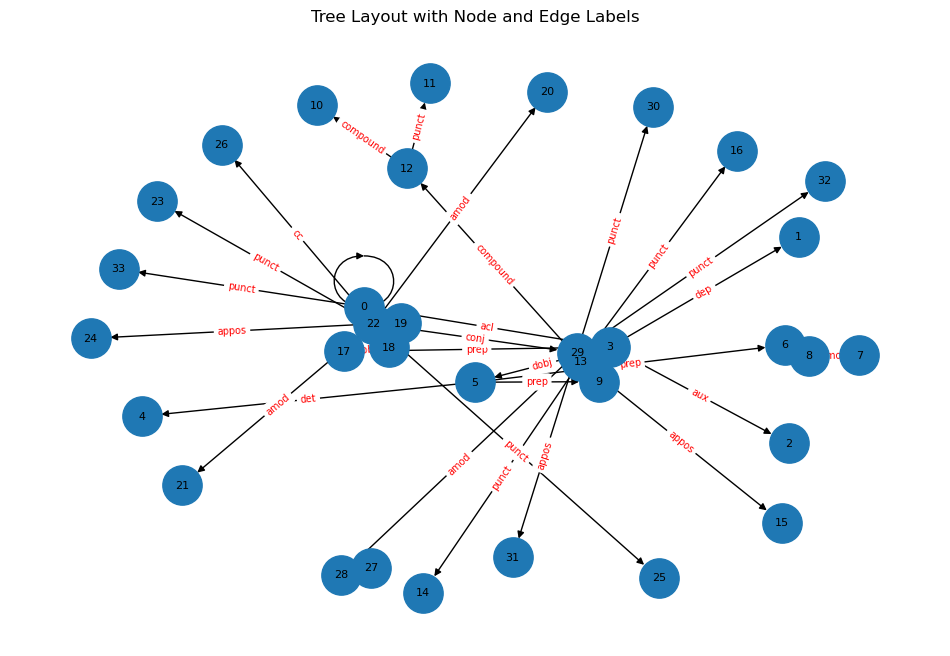

In [42]:
import matplotlib.pyplot as plt
import networkx as nx

# Your graph
G = graphs[5120]  # Replace with your graph

# Compute tree layout (requires Graphviz via pygraphviz or pydot)
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
except:
    print("Graphviz not available, falling back to spring layout")
    pos = nx.spring_layout(G)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))
# Draw graph
nx.draw(
    G,
    pos,
    ax=ax,
    with_labels=True,
    node_size=800,
    font_size=8,
    arrows=True
)
# Draw edge labels (change 'label' to your actual edge attribute name)
edge_labels = nx.get_edge_attributes(G, 'feature')
print(pos)
nx.draw_networkx_edge_labels(G, pos, 
                             edge_labels=edge_labels,
                             font_color='red', 
                             font_size=7)
ax.axis("off")
plt.title("Tree Layout with Node and Edge Labels")
plt.show()


In [44]:
graphs[5120]
for node, attrs in graphs[5120].nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges:")
for u, v, attrs in G.edges(data=True):
    print(f"  {u} -> {v}: {attrs}")
print("\n"
      "-----------------------------------\n"
      )

graph_test = graphs[5120]
print(graph_test.nodes[0])
graph_test.nodes[0]['feature'] = graphs[5120].nodes[1]['feature']
graph_test.nodes[0]

  0: {'feature': 'NOUN', 'is_root': False}
  1: {'feature': 'SPACE', 'is_root': False}
  2: {'feature': 'PART', 'is_root': False}
  3: {'feature': 'VERB', 'is_root': False}
  4: {'feature': 'DET', 'is_root': False}
  5: {'feature': 'NOUN', 'is_root': False}
  6: {'feature': 'ADP', 'is_root': False}
  7: {'feature': 'ADJ', 'is_root': False}
  8: {'feature': 'NOUN', 'is_root': False}
  9: {'feature': 'ADP', 'is_root': False}
  10: {'feature': 'NOUN', 'is_root': False}
  11: {'feature': 'PUNCT', 'is_root': False}
  12: {'feature': 'NOUN', 'is_root': False}
  13: {'feature': 'NOUN', 'is_root': False}
  14: {'feature': 'PUNCT', 'is_root': False}
  15: {'feature': 'PROPN', 'is_root': False}
  16: {'feature': 'PUNCT', 'is_root': False}
  17: {'feature': 'ADP', 'is_root': False}
  18: {'feature': 'NOUN', 'is_root': False}
  19: {'feature': 'ADP', 'is_root': False}
  20: {'feature': 'ADJ', 'is_root': False}
  21: {'feature': 'VERB', 'is_root': False}
  22: {'feature': 'NOUN', 'is_root': False}


{'feature': 'SPACE', 'is_root': False}

In [46]:
graphs[len(graphs)] = graph_test

In [47]:
from karateclub import Graph2Vec
from karateclub import GL2Vec
# model = Graph2Vec(wl_iterations=1, dimensions=16,
#                   attributed=True, workers=24, epochs=20,
#                   min_count=2, learning_rate=0.1)
# model.fit(list(graphs.values()))
# embeddings = model.get_embedding()
# embeddings_data = np.array(embeddings)
# np.savez_compressed("graph2vec_embeddings.npz", embeddings_data)
hiper = {'wl_iterations': 1, 'dimensions': 16, 'workers': 24, 'learning_rate': 0.04, 'min_count': 2, 'epochs': 20}
# Train GL2Vec (better for directed graphs)
model_gl = GL2Vec(**hiper)
model_gl.fit(list(graphs.values()))
embeddings_gl = model_gl.get_embedding()
embeddings_gl_data = np.array(embeddings_gl)
# # np.savez_compressed("gl2vec_embeddings.npz", embeddings_gl_data)

In [86]:
from sklearn.preprocessing import normalize
embs = []
emb_g = model_gl.infer([graphs[5120]])
for i in range(3):
    embs.append(model_gl.infer([graphs[5120]]))
    print(cosine_similarity(model_gl.infer([graphs[5120]]), emb_g))
    print(euclidean_distances(model_gl.infer([graphs[5120]]), emb_g))
embs

[[0.97865236]]
[[0.4811583]]
[[0.98788065]]
[[0.48001143]]
[[0.9854322]]
[[0.5701041]]


[array([[-0.13189583,  0.21086349, -0.19681019, -1.2642822 ,  0.2543869 ,
          0.4982598 ,  0.7596955 ,  0.04400064, -0.47142836,  0.5449566 ,
         -0.6204158 , -0.17453638,  0.03288005,  0.92180926, -0.6496193 ,
         -0.07002988]], dtype=float32),
 array([[-0.05252774,  0.3101957 , -0.10946125, -1.2385719 ,  0.27867082,
          0.47950548,  0.73764336,  0.09918732, -0.44937634,  0.5907665 ,
         -0.5016072 , -0.1779411 ,  0.02132247,  0.8917271 , -0.6095585 ,
         -0.11951527]], dtype=float32),
 array([[-0.21292096,  0.23774138, -0.231088  , -1.3599967 ,  0.31177926,
          0.48843366,  0.74760884,  0.00154492, -0.4851239 ,  0.6727877 ,
         -0.47756118, -0.2051084 , -0.06649587,  0.925262  , -0.4682194 ,
         -0.0260914 ]], dtype=float32)]

In [83]:
em = normalize(np.vstack(embs))

In [85]:
euclidean_distances([em[0]], [em[1]])

array([[0.12304147]], dtype=float32)

In [88]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

x = embs[0]
y = embs[1]

# Normalize properly
x_n = x / np.linalg.norm(x)
y_n = y / np.linalg.norm(y)

cos_sim = cosine_similarity(x_n, y_n)[0][0]
eucl = np.linalg.norm(x_n - y_n)

print("cosine similarity:", cos_sim)
print("euclidean distance normalized:", eucl)
print("relation:", eucl**2, " ≈ ", 2*(1 - cos_sim))


cosine similarity: 0.99501187
euclidean distance normalized: 0.099881195
relation: 0.00997625302112276  ≈  0.00997626781463623


In [ ]:
emb_te = model_gl.infer([graphs[5120]])

array([[-0.21034403,  0.20952176, -0.1765891 , -1.2736912 ,  0.29515383,
         0.44836536,  0.80323374,  0.18615626, -0.41625378,  0.65966743,
        -0.53586864, -0.26472124,  0.02304676,  0.84531677, -0.60649985,
         0.08093981]], dtype=float32)

In [ ]:
printa(embeddings_gl_data[5120])
print(embeddings_gl_data[-1])

[-0.3703028  -0.13873121 -0.20551139 -0.16468593  0.6813766   0.30311576
  0.65667576  0.48526314 -0.38678375  0.44566247 -0.4383305   0.3566159
 -0.68685466  0.2674412  -0.06051065  0.40249333]
[-0.16390464  0.3630627  -0.14194123 -1.1468723   0.23257087  0.502549
  0.65052813  0.04781638 -0.27612898  0.539832   -0.5141303  -0.16192296
 -0.05473752  0.6085029  -0.4149943  -0.02609069]


In [78]:
type(embeddings_gl_data)

numpy.ndarray

In [77]:
normalize(embeddings_gl_data)

array([[-0.05621522,  0.08777184, -0.00082586, ..., -0.1631513 ,
        -0.288481  ,  0.23139632],
       [-0.13269351,  0.10586736,  0.23180294, ...,  0.06048045,
        -0.5347926 ,  0.1908479 ],
       [-0.14605206,  0.02388133, -0.2771569 , ..., -0.38613766,
        -0.13053237,  0.24540237],
       ...,
       [-0.1383497 , -0.07265677, -0.03598763, ..., -0.2309977 ,
        -0.5144422 ,  0.02861608],
       [ 0.18220185,  0.11615229,  0.05309602, ..., -0.2604432 ,
        -0.5721045 ,  0.20475943],
       [-0.08849182,  0.19601691, -0.07663382, ...,  0.32852963,
        -0.22405468, -0.01408632]], dtype=float32)

In [59]:
embeddings_gl_data[-1].shape

(16,)

In [62]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
cosine_similarity([embeddings_gl_data[5120]], 
                  [embeddings_gl_data[-1]])


array([[0.55233294]], dtype=float32)

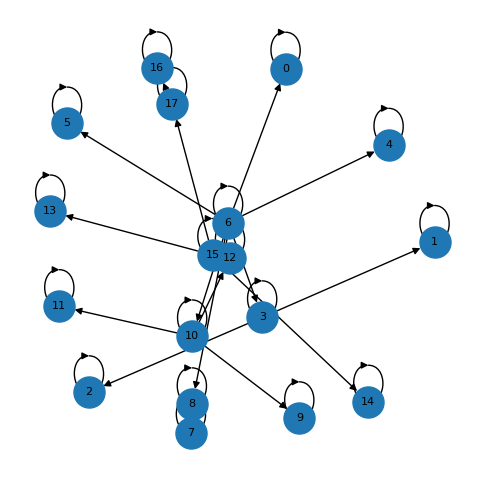

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(6, 6))  # Create a new figure
ax = plt.gca()              # Get current axes
nx.draw(graphs[4601], ax=ax, with_labels=True, node_size=500, font_size=8)
plt.show()

In [9]:
#Query neighbors for a few examples
import json
def print_transposed_aligned(*lists, labels=None):
    # Ensure all lists are the same length
    length = len(lists[0])
    assert all(len(lst) == length for lst in lists), "All lists must have the same length"

    # Convert all items to strings
    lists = [[str(item) for item in lst] for lst in lists]

    # Compute column widths per index
    col_widths = [max(len(lists[row][col]) for row in range(len(lists))) for col in range(length)]

    # Print labels (optional)
    if labels:
        print("\t".join(f"{label:<{max(col_widths)}}" for label in labels))
        print("-" * (sum(col_widths) + 4 * len(col_widths)))

    # Print each list as a row
    for i, lst in enumerate(lists):
        print("\t".join(f"{item:<{col_widths[j]}}" for j, item in enumerate(lst)))

# # Example usage
# tokens = df[i].tokens
# pos = data_list[i]['pos']
# dep = data_list[i]['dep']
# parents = data_list[i]['parents']

# print_transposed_aligned(tokens, pos, dep, parents, labels=["Token", "POS", "Dep", "Parent"])
# print(f"\nSentence length: {len(tokens)}")

df = pd.read_json('/home/mkeber/syn-bioner/bioNER/data/ncbi/trf/ncbi_ner_train.json')

def show_neighbors(index, data_list, knn, ids):
  X = [sample["embedding"] for sample in data_list]
  distances, indices = knn.kneighbors([X[index]])
  print(f"Neighbors for sample id={ids[index]}:")
  for d, i in zip(distances[0], indices[0]):
      print(f"id={ids[i]}, {i},  distance={d:.4f}, sentence=\n{data_list[i]['sentence']}")
      # print(f"original sent: {df[i].tokens} ")
      # print(f"pos={data_list[i]['pos']}\n dep={data_list[i]['dep']}\n parents={data_list[i]['parents']}")
      print(f"sentence length: {len(data_list[i]['pos'])}"),
      print_transposed_aligned(df.loc[i,'tokens'], data_list[i]['pos'], data_list[i]['dep'], 
                            data_list[i]['parents'])

      print("*"*80)

In [10]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

data = pd.read_json("/home/mkeber/syn-bioner/bioNER/data/ncbi/trf/syntax_features/syntax_features_sent_tree_head.json")
# Load embeddings
# embeddings_data = np.load("/content/gl2vec_embeddings.npz", allow_pickle=True)
embeddings = embeddings_gl # embeddings_data["arr_0"]
data["embedding"] = [embeddings[i] for i in range(len(embeddings))]

#filter to look only at NCBI
data_NCBI = data[data["corpus"] == "NCBI_train"]
ids = data_NCBI["id"].tolist()
X = np.vstack(data_NCBI["embedding"].values)

# Fit KNN model
k = 5  # number of neighbors to fetch
knn = NearestNeighbors(n_neighbors=k, metric="cosine")
knn.fit(X)

# Show neighbors for first few samples
for idx in range(min(3, len(X))):
    print()
    print('#'*40)
    print('NEW NEIGHBOURHOOD: ')
    show_neighbors(idx, data_NCBI.to_dict('records'), knn, ids)


########################################
NEW NEIGHBOURHOOD: 
Neighbors for sample id=1:
id=1, 0,  distance=0.0000, sentence=
A common human skin tumour is caused by activating mutations in beta-catenin.
sentence length: 15
A  	common	human	skin    	tumour   	is     	caused	by   	activating	mutations	in  	beta    	-    	catenin	.    
DET	ADJ   	ADJ  	NOUN    	NOUN     	AUX    	VERB  	ADP  	VERB      	NOUN     	ADP 	NOUN    	PUNCT	NOUN   	PUNCT
det	amod  	amod 	compound	nsubjpass	auxpass	ROOT  	agent	amod      	pobj     	prep	compound	punct	pobj   	punct
4  	4     	4    	4       	6        	6      	6     	6    	9         	7        	9   	13      	13   	10     	6    
********************************************************************************
id=4607, 4606,  distance=0.2711, sentence=
One probe, p31, was shown to cover one of the breakpoints of the smallest deletion.
sentence length: 18
One   	probe    	,    	p31  	,    	was    	shown	to  	cover	one 	of  	the	breakpoints	of  	the	small

In [11]:
# Find the k nearest neighbors for each point in X
distances, indices = knn.kneighbors(X)

# Add neighbor IDs to the dataframe
neighbor_ids = [[ids[idx] for idx in row] for row in indices]

# Add sum of distances for the 5 neighbors
sum_distances = distances.sum(axis=1)

# Add results to dataframe
data_NCBI = data_NCBI.reset_index(drop=True)  # Ensure index alignment
data_NCBI['nearest_neighbors'] = neighbor_ids
data_NCBI['sum_distances'] = sum_distances

<Axes: >

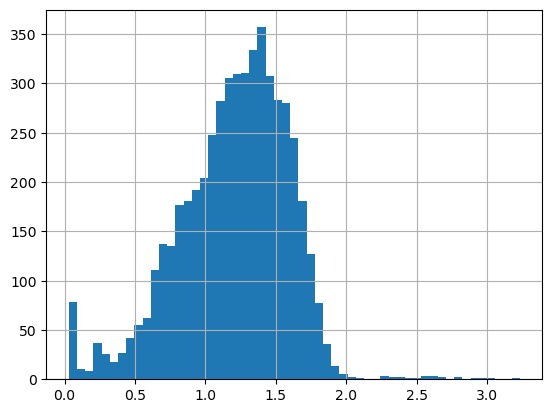

In [12]:
data_NCBI['sum_distances'].hist(bins='fd')

In [13]:
show_neighbors(5112, data_NCBI.to_dict('records'), knn, ids)

Neighbors for sample id=5113:
id=5113, 5112,  distance=0.0000, sentence=
The arginine 188 mutation is the most common galactosemia mutation characterized to date.
sentence length: 14
The	arginine	188   	mutation	is  	the	most  	common	galactosemia	mutation	characterized	to  	date	.    
DET	NOUN    	NUM   	NOUN    	AUX 	DET	ADV   	ADJ   	NOUN        	NOUN    	VERB         	ADP 	NOUN	PUNCT
det	nmod    	nummod	nsubj   	ROOT	det	advmod	amod  	compound    	attr    	acl          	prep	pobj	punct
3  	3       	1     	4       	4   	9  	7     	9     	9           	4       	9            	10  	11  	4    
********************************************************************************
id=104, 103,  distance=0.1800, sentence=
Eighteen (69%) of 26 mutations were missense mutations.
sentence length: 12
Eighteen	(    	69    	%    	)    	of  	26    	mutations	were	missense	mutations	.    
NUM     	PUNCT	NUM   	NOUN 	PUNCT	ADP 	NUM   	NOUN     	AUX 	NOUN    	NOUN     	PUNCT
nsubj   	punct	nummod	appos	pun

In [31]:
data_NCBI.sort_values(['sum_distances'])[-40:]

,id,sentence,entities,corpus,pos,dep,parents,embedding,nearest_neighbors,sum_distances
784,785,The IQ of PAH-deficient mothers with a severe ...,"[PAH-deficient, MHP, PKU]",NCBI_train,"[DET, NOUN, ADP, PROPN, PUNCT, ADJ, NOUN, ADP,...","[det, nsubj, prep, npadvmod, punct, amod, pobj...","[1, 23, 1, 5, 5, 6, 2, 6, 11, 11, 11, 7, 11, 1...","[1.3180535, -0.1724738, 0.3880684, -1.0869004,...","[785, 2024, 3017, 2783, 1672]",1.915273
2020,2021,"Three congenital anomaly disorders, cat-eye sy...","[velo-cardio-facial syndrome, DGS, VCFS, conge...",NCBI_train,"[NUM, ADJ, NOUN, NOUN, PUNCT, NOUN, PUNCT, NOU...","[nummod, amod, compound, nsubjpass, punct, com...","[3, 2, 3, 30, 3, 7, 7, 8, 3, 8, 13, 13, 13, 8,...","[0.039715283, -0.014289971, -0.5127608, 0.2678...","[2021, 4232, 4917, 2277, 3119]",1.916577
3148,3149,The study group consisted of 66 Polish familie...,"[cancer, breast or ovarian cancer]",NCBI_train,"[DET, NOUN, NOUN, VERB, ADP, NUM, ADJ, NOUN, A...","[det, compound, nsubj, ROOT, prep, nummod, amo...","[2, 2, 3, 3, 3, 7, 7, 4, 7, 8, 11, 7, 13, 14, ...","[0.29844257, 0.06928932, 0.14914507, 0.1793480...","[3149, 3357, 4059, 1073, 1767]",1.917519
2999,3000,Cleft types (CLP and CP) occur in VWS in the s...,"[CLP, VWS, CP]",NCBI_train,"[ADJ, NOUN, PUNCT, PROPN, CCONJ, PROPN, PUNCT,...","[compound, nsubj, punct, appos, cc, conj, punc...","[1, 7, 1, 1, 3, 3, 1, 33, 7, 8, 7, 13, 13, 10,...","[0.5327495, 0.15034303, 0.09276998, 0.3638844,...","[3000, 903, 4812, 4633, 3902]",1.931355
2716,2717,The other five variants were new Gd (-) Lagho...,[],NCBI_train,"[DET, ADJ, NUM, NOUN, AUX, PROPN, SPACE, PROPN...","[det, amod, nummod, nsubj, ROOT, nmod, dep, at...","[3, 3, 3, 4, 4, 6, 4, 6, 11, 8, 11, 7, 11, 14,...","[0.37503445, -0.3342027, 0.36694357, 0.1094623...","[2717, 146, 2756, 609, 5029]",1.932346
1613,1614,"The first, of Italian extraction, suffered fro...",[neonatal jaundice],NCBI_train,"[DET, ADJ, PUNCT, ADP, ADJ, NOUN, PUNCT, VERB,...","[det, nsubj, punct, prep, amod, pobj, punct, c...","[1, 7, 1, 1, 5, 3, 1, 27, 7, 11, 11, 8, 7, 14,...","[-0.5258613, -0.3976803, -0.39756337, 0.180985...","[1614, 1671, 4298, 1830, 3452]",1.938166
1120,1121,Glucose 6-phosphate dehydrogenase (G6PD) is a ...,[],NCBI_train,"[NOUN, NUM, PUNCT, NOUN, NOUN, PUNCT, NOUN, PU...","[compound, nummod, punct, compound, nsubj, pun...","[4, 3, 3, 4, 8, 4, 4, 4, 8, 11, 11, 8, 11, 12,...","[0.16830234, -0.1544112, 0.21321476, -0.061590...","[1121, 2062, 4362, 1182, 3094]",1.941061
1231,1232,"Alternatively, the very tight association of H...",[],NCBI_train,"[ADV, PUNCT, DET, ADV, ADJ, NOUN, ADP, PROPN, ...","[advmod, punct, det, advmod, amod, nsubj, prep...","[36, 36, 5, 4, 5, 36, 5, 9, 9, 6, 9, 9, 11, 11...","[0.13264234, -0.12232991, 0.13473953, 0.346525...","[1232, 4393, 302, 589, 334]",1.944098
474,475,Our findings revealed the following characteri...,"[APC, FAP]",NCBI_train,"[PRON, NOUN, VERB, DET, ADJ, NOUN, ADP, DET, N...","[poss, nsubj, ROOT, det, amod, dobj, prep, det...","[1, 2, 2, 5, 5, 2, 5, 11, 10, 10, 11, 6, 11, 1...","[0.6663368, 0.3250112, 0.7688307, 0.001272555,...","[475, 1696, 3957, 1184, 3442]",1.949795
1123,1124,From the alignment of the amino acid (aa) sequ...,[G6PD deficiency],NCBI_train,"[ADP, DET, NOUN, ADP, DET, NOUN, NOUN, PUNCT, ...","[prep, det, pobj, prep, det, nmod, nmod, punct...","[28, 2, 0, 2, 10, 6, 10, 6, 6, 8, 3, 10, 21, 1...","[0.2804838, -0.10643726, -0.26187056, 0.145236...","[1124, 3906, 2947, 4628, 1841]",1.961661


In [16]:
from sklearn.metrics import pairwise_distances
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Simple sequence-overlap similarity (Jaccard)
def jaccard_similarity(list1, list2):
    s1, s2 = set(list1), set(list2)
    return len(s1 & s2) / len(s1 | s2) if s1 | s2 else 0

# POS + DEP combined syntactic similarity
def syntactic_similarity(a, b):
    pos_sim = jaccard_similarity(a["pos"], b["pos"])
    dep_sim = jaccard_similarity(a["dep"], b["dep"])
    return 0.5 * (pos_sim + dep_sim)


In [ ]:
from sklearn.neighbors import NearestNeighbors

def avg_syntactic_sim_for_embedding(idx, data, knn):
  X = [sample["embedding"] for sample in data]
  distances, indices = knn.kneighbors([X[idx]])
  sims = []
  for i in indices[0][1:]:  # skip self
      sims.append(syntactic_similarity(data[idx], data[i]))
  return np.mean(sims)

syntactic_sims = [avg_syntactic_sim_for_embedding(i, data_NCBI.to_dict('records'), knn
                                                  ) for i in range(len(data_NCBI))]
print("Average syntactic similarity among neighbors:", np.mean(syntactic_sims))

In [19]:
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

# --- helper functions ---
def jaccard_similarity(list1, list2):
    s1, s2 = set(list1), set(list2)
    return len(s1 & s2) / len(s1 | s2) if s1 | s2 else 0

def syntactic_similarity(a, b):
    pos_sim = jaccard_similarity(a["pos"], b["pos"])
    dep_sim = jaccard_similarity(a["dep"], b["dep"])
    avg_sim = 0.5 * (pos_sim + dep_sim)
    return pos_sim, dep_sim, avg_sim


# --- compute syntactic similarities only for KNN neighbors ---
def compute_knn_syntactic_similarities(data, knn):
    """
    Compute syntactic similarities only between each sample and its k nearest neighbors.

    Parameters
    ----------
    data : list[dict]
        Each dict must have keys "embedding", "pos", and "dep".
    knn : sklearn.neighbors.NearestNeighbors
        Pre-fitted NearestNeighbors model (on embeddings).

    Returns
    -------
    pos_sim, dep_sim, avg_sim : np.ndarray
        Symmetric similarity matrices (n x n)
    """
    n = len(data)
    X = [d["embedding"] for d in data]
    distances, indices = knn.kneighbors(X)

    pos_sim = np.zeros((n, n))
    dep_sim = np.zeros((n, n))
    avg_sim = np.zeros((n, n))

    # Collect all unique (i, j) neighbor pairs (skip self)
    pairs = [(i, j) for i, neighs in enumerate(indices)
                    for j in neighs[1:] if i < j]

    # Parallel computation
    results = Parallel(n_jobs=-1, backend='loky')(
        delayed(syntactic_similarity)(data[i], data[j]) for i, j in tqdm(pairs)
    )

    # Fill matrices symmetrically
    for (i, j), (p, d, a) in zip(pairs, results):
        pos_sim[i, j] = pos_sim[j, i] = p
        dep_sim[i, j] = dep_sim[j, i] = d
        avg_sim[i, j] = avg_sim[j, i] = a

    return pos_sim, dep_sim, avg_sim


# --- Example usage ---
data_records = data_NCBI.to_dict('records')
pos_sim, dep_sim, avg_sim = compute_knn_syntactic_similarities(data_records, knn)

# Compute global means over nonzero entries (since not all pairs exist)
mask = np.triu(pos_sim, 1) > 0
print("Mean POS similarity:", pos_sim[mask].mean())
print("Mean DEP similarity:", dep_sim[mask].mean())
print("Mean average similarity:", avg_sim[mask].mean())


100%|██████████| 10342/10342 [00:08<00:00, 1188.84it/s]


Mean POS similarity: 0.6476434785205011
Mean DEP similarity: 0.5416460584151913
Mean average similarity: 0.5946447684678462


In [ ]:
syntactic_sims[:20]

In [20]:
import random

def random_syntactic_similarity(data, n=10000):
    sims = []
    pairs = [tuple(random.sample(range(len(data)), 2)) for _ in range(n)]
    results = Parallel(n_jobs=-1, backend='loky')(
        delayed(syntactic_similarity)(data[i], data[j]) for i, j in tqdm(pairs)
    )

    pos_sims, dep_sims, avg_sims = zip(*results)
    return (
        np.mean(pos_sims),
        np.mean(dep_sims),
        np.mean(avg_sims)
    )   
pos_rand, dep_rand, avg_rand = random_syntactic_similarity(data_records)
print(f"Random baseline POS sim: {pos_rand:.4f}")
print(f"Random baseline DEP sim: {dep_rand:.4f}")
print(f"Random baseline AVG sim: {avg_rand:.4f}")
print(f"Improvement (avg): {(avg_sim[mask].mean() - avg_rand):.4f}")


100%|██████████| 10000/10000 [00:04<00:00, 2189.83it/s]


Random baseline POS sim: 0.5940
Random baseline DEP sim: 0.4760
Random baseline AVG sim: 0.5350
Improvement (avg): 0.0597


In [47]:
!pip install hdbscan


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 8.6 MB/s eta 0:00:00ta 0:00:01


In [26]:
embeddings_data = np.load("/content/gl2vec_embeddings.npz")
print(embeddings_data.files)

['arr_0']


Probli smo: wl_iterations više nije bolje

learning_rate oko 0.1 default nije dobar

epochs oko 20 epoha

Pomaže ako uključimo atribute zapravo imena čvorova.


In [ ]:
embeddings.shape
corpus = [d.get("corpus") for d in data]

In [23]:
import umap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=25,        # similar to t-SNE perplexity
    min_dist=0.1,          # controls cluster tightness
    metric="cosine",       # works well for text features
    # random_state=42,
    n_jobs=48,
)

X_umap = umap_model.fit_transform(embeddings)
# Create interactive scatter plot
np.shape(X_umap)

 21%|██        | 2824895/13668606 [23:52<1:31:37, 1972.34it/s]


(14008, 2)

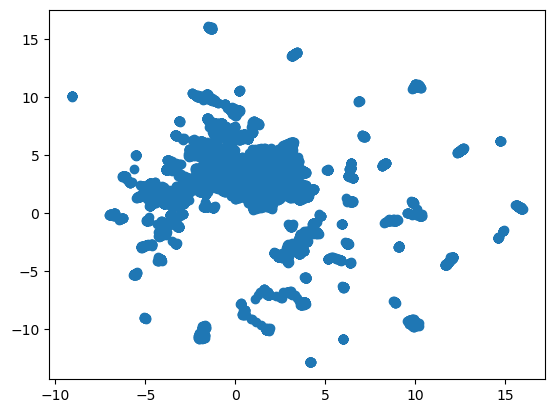

In [24]:
fig = plt.scatter(X_umap[:,0], X_umap[:,1])

UMAP grid rows:   0%|          | 0/5 [00:00<?, ?it/s]No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
UMAP grid rows:  20%|██        | 1/5 [00:12<00:49, 12.39s/it]No artists with labels found to put in legend.  Note that artists whose label start with an underscor

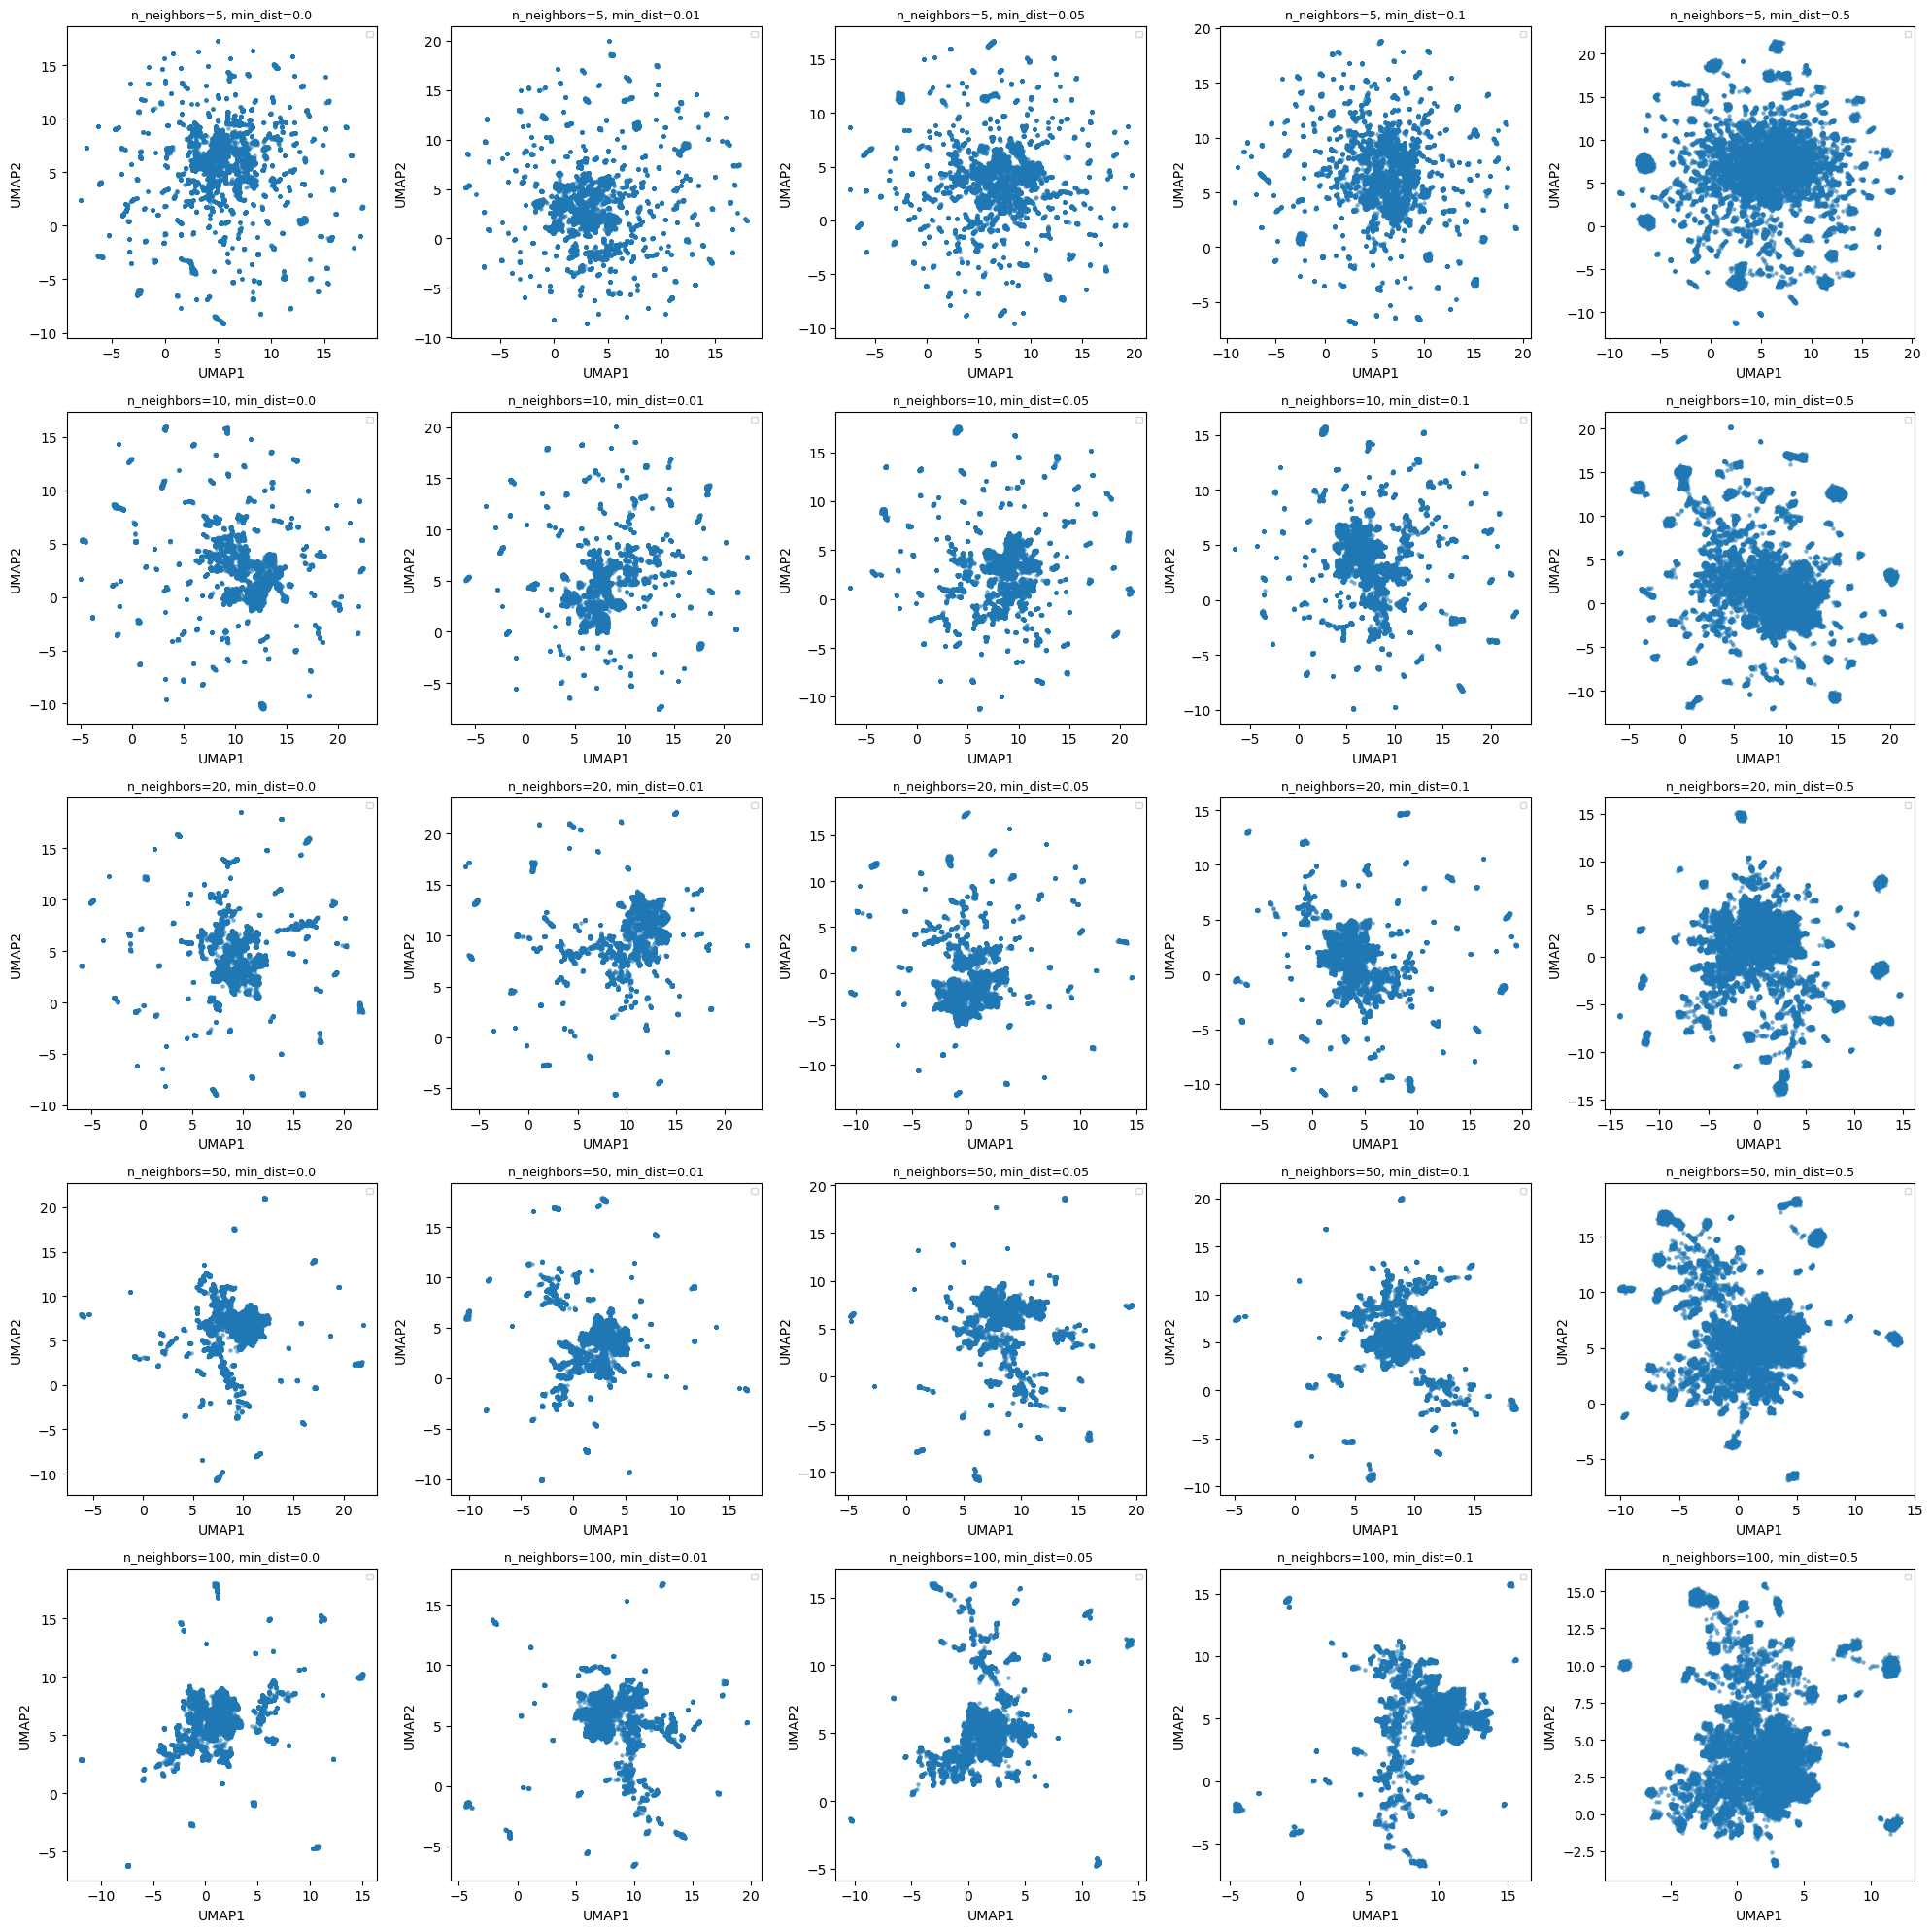

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from tqdm import tqdm

# Example: embeddings = np.random.randn(1000, 384)
# and df['corpus'] = some categorical labels of same length

# --- parameter grids ---
neighbors = [5, 10, 20, 50, 100]
min_dists = [0.0, 0.01, 0.05, 0.1, 0.5]

n_rows = len(neighbors)
n_cols = len(min_dists)

# --- plotting setup ---
fig_all, axes_all = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

# Ensure we have the dataframe with corpus labels
# df = pd.DataFrame({"corpus": corpus_labels})  # replace with your actual label array

# --- loop over parameter grid ---
for i, n_neighbors in enumerate(tqdm(neighbors, desc="UMAP grid rows")):
    for j, min_dist in enumerate(min_dists):
        ax = axes_all[i, j]

        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="cosine",
            n_jobs=48,
            # random_state=42
        )

        X_umap = reducer.fit_transform(embeddings)

        # add to dataframe for plotting
        df_plot = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
        # df_plot["corpus"] = df["corpus"]

        sns.scatterplot(
            data=df_plot,
            x="UMAP1", y="UMAP2",
            # hue="corpus",
            ax=ax,
            alpha=0.6, s=10, linewidth=0
        )

        ax.set_title(f"n_neighbors={n_neighbors}, min_dist={min_dist}", fontsize=9)
        ax.legend(fontsize=6, loc='best')

# --- finalize ---
plt.tight_layout()
plt.show()


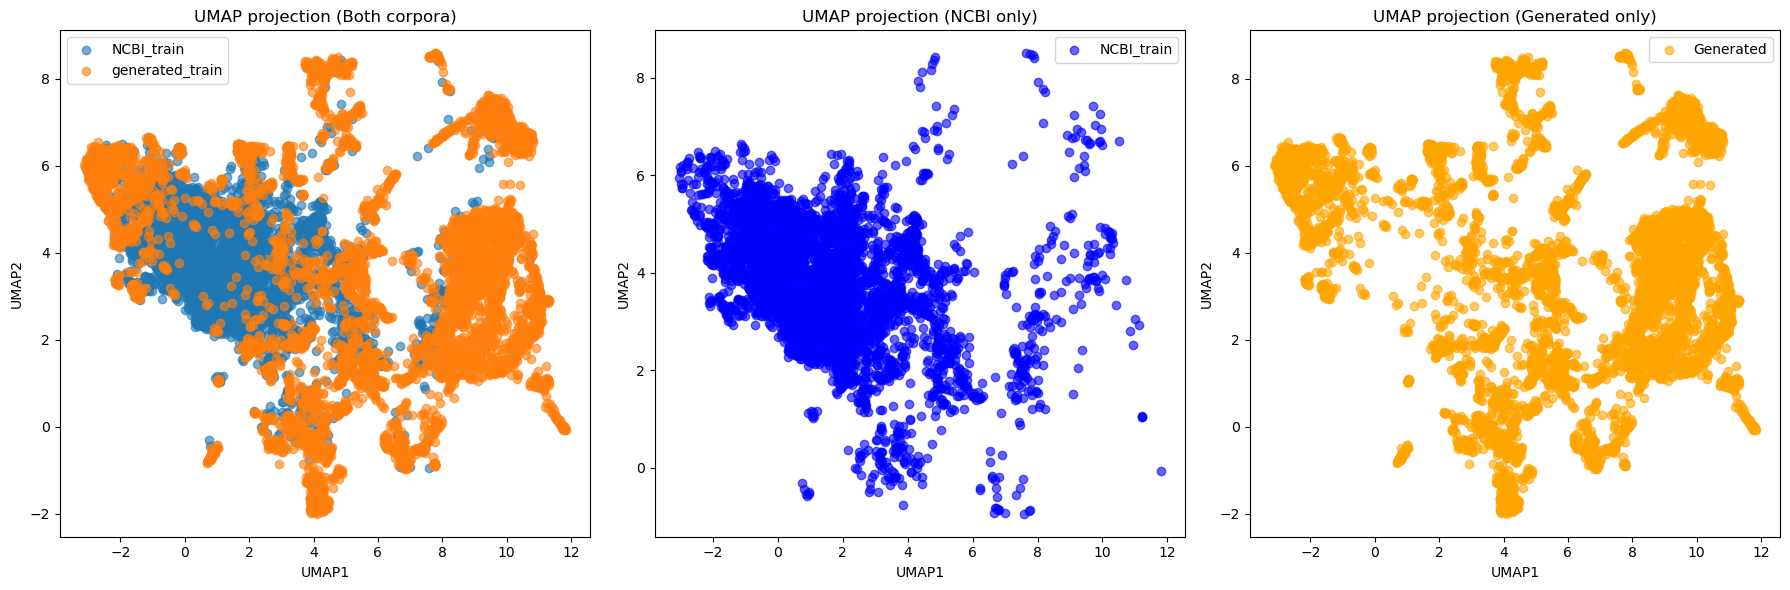

In [ ]:
import umap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=25,        # similar to t-SNE perplexity
    min_dist=0.1,          # controls cluster tightness
    metric="cosine",       # works well for text features
    # random_state=42,
    n_jobs=48,
)

X_umap = umap_model.fit_transform(embeddings)

# Save model for later reuse
# joblib.dump(umap_model, "syntax_umap.pkl")

df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df["corpus"] = corpus

df_ncbi = df[df["corpus"] == "NCBI_train"]
df_gen = df[df["corpus"] == "generated_train"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Both datasets ---
ax = axes[0]
for corpus_name, group in df.groupby("corpus"):
    ax.scatter(group["UMAP1"], group["UMAP2"], alpha=0.6, label=corpus_name)
ax.legend()
ax.set_title("UMAP projection (Both corpora)")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# --- 2. NCBI only ---
bx = axes[1]
bx.scatter(df_ncbi["UMAP1"], df_ncbi["UMAP2"], alpha=0.6, color="blue", label="NCBI_train")
bx.legend()
bx.set_title("UMAP projection (NCBI only)")
bx.set_xlabel("UMAP1")
bx.set_ylabel("UMAP2")

# --- 3. Generated only ---
cx = axes[2]
cx.scatter(df_gen["UMAP1"], df_gen["UMAP2"], alpha=0.6, color="orange", label="Generated")
cx.legend()
cx.set_title("UMAP projection (Generated only)")
cx.set_xlabel("UMAP1")
cx.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

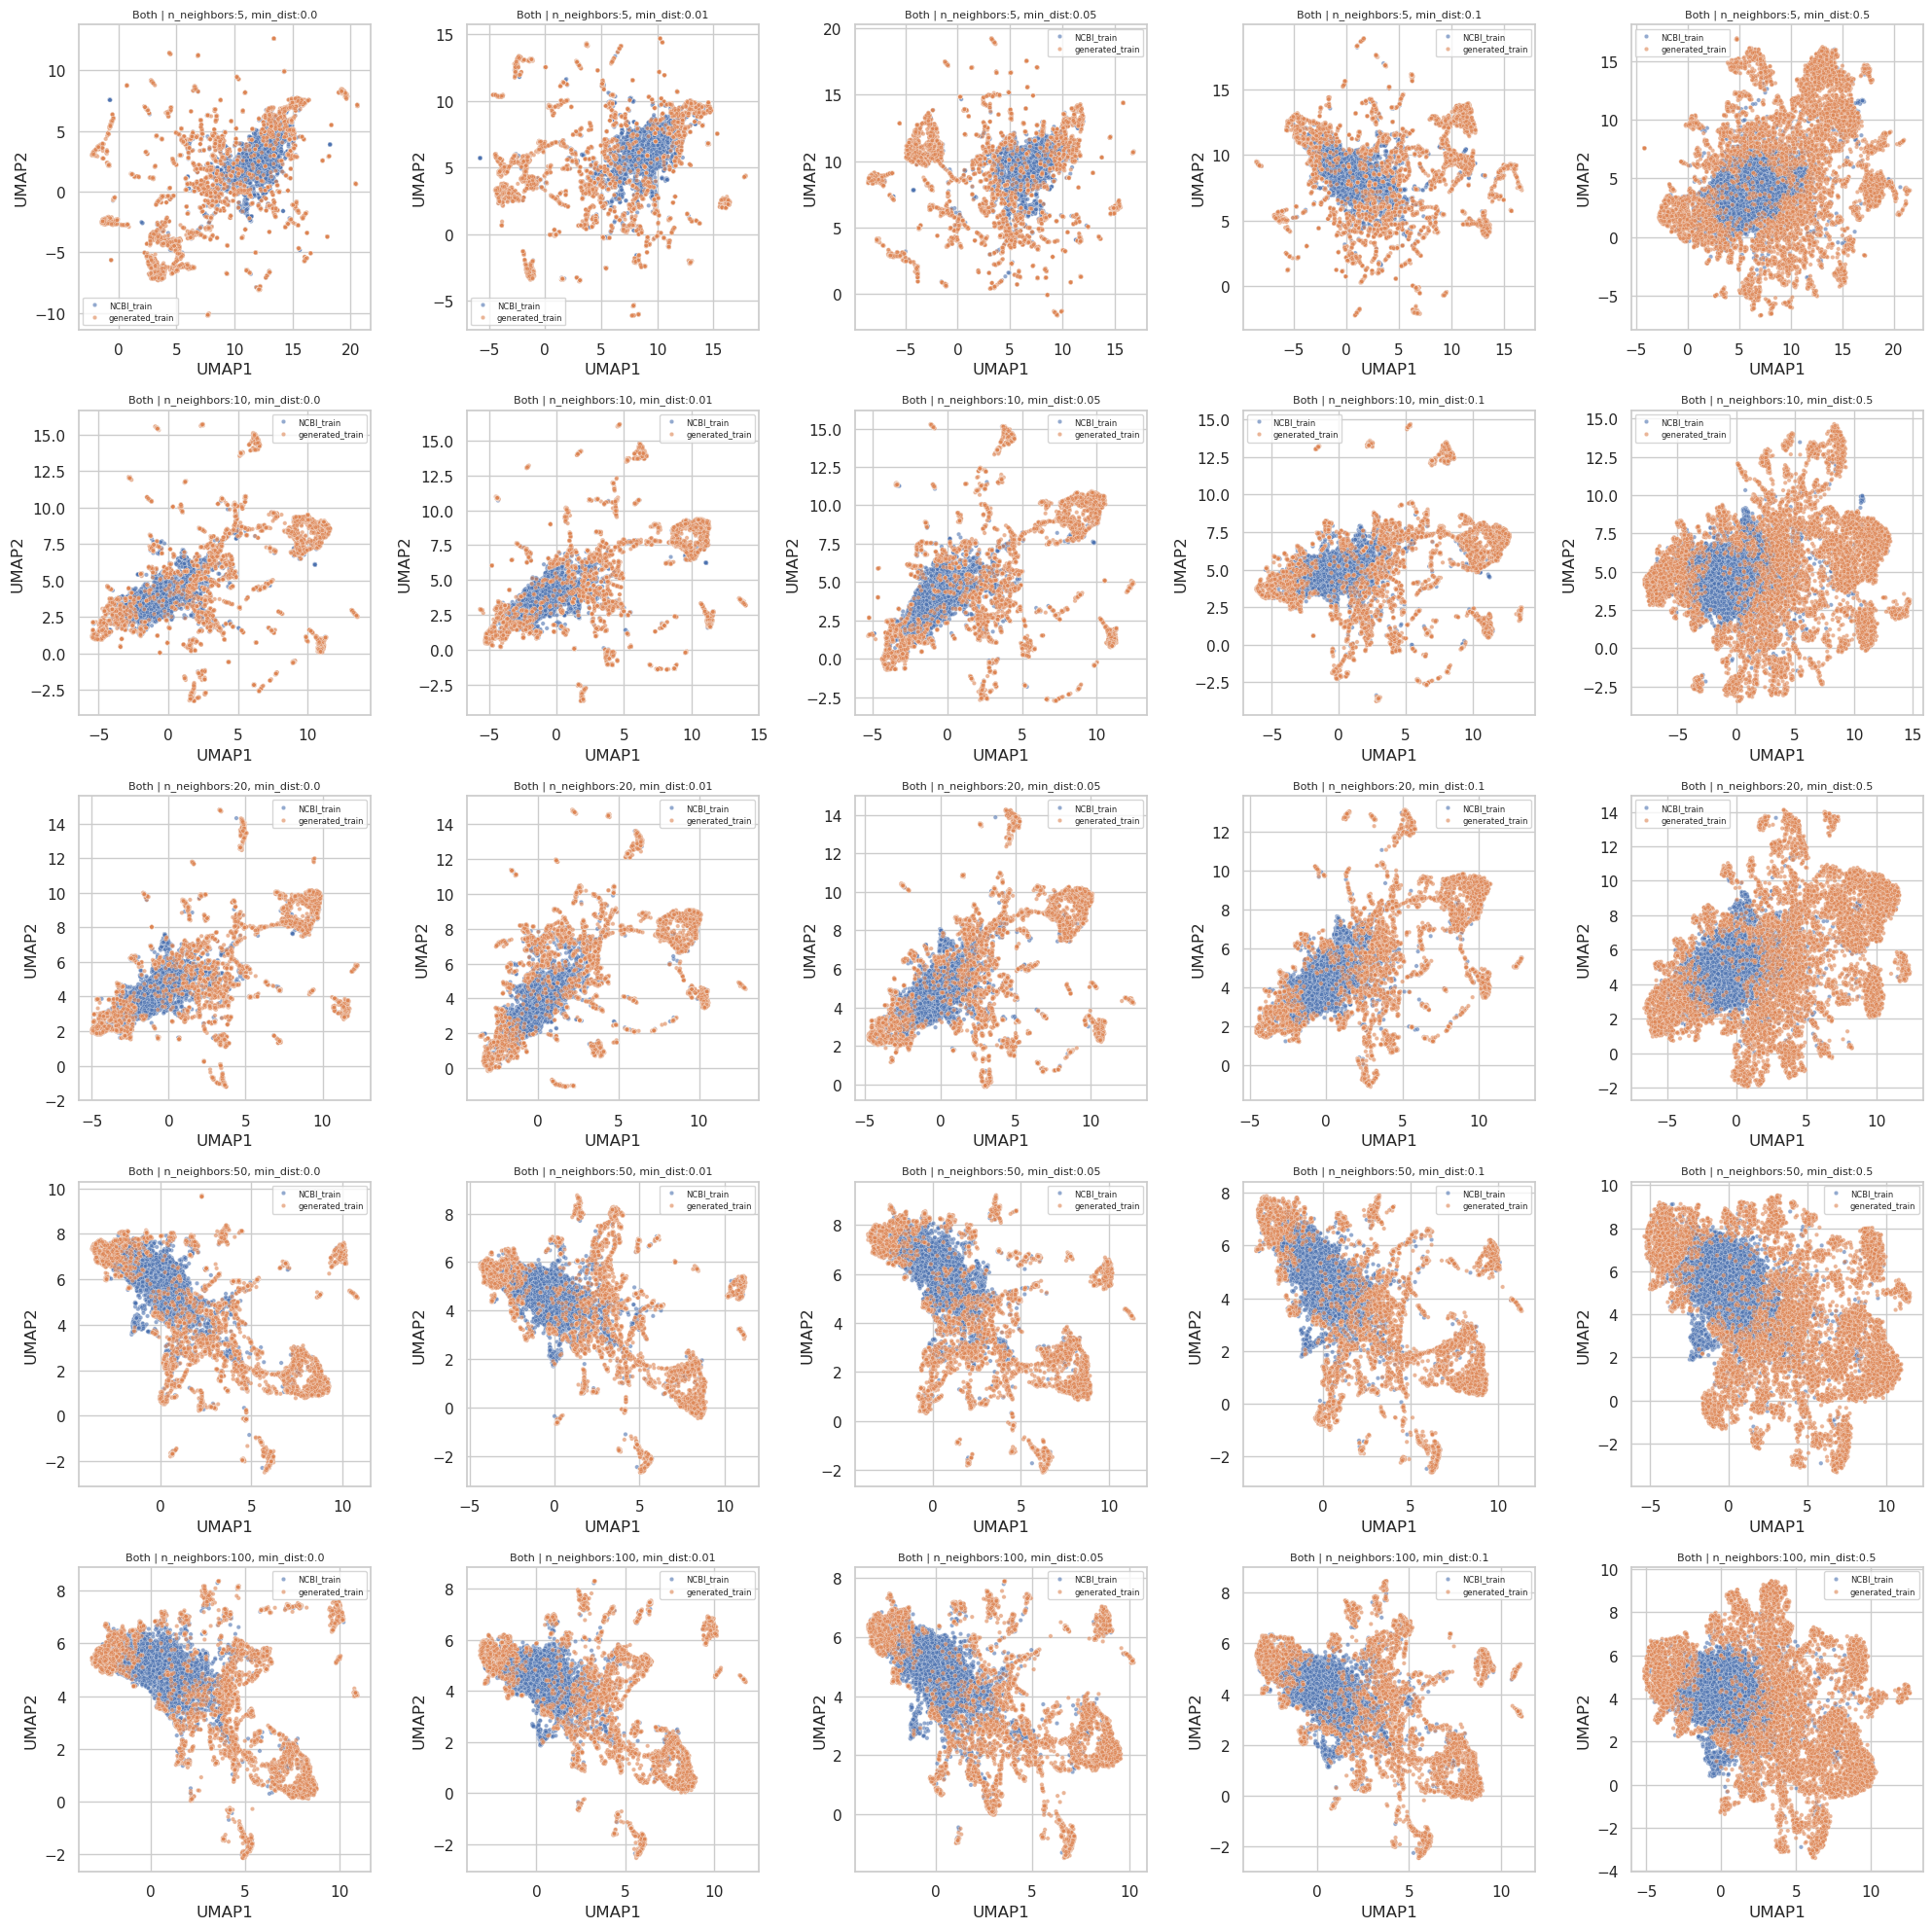

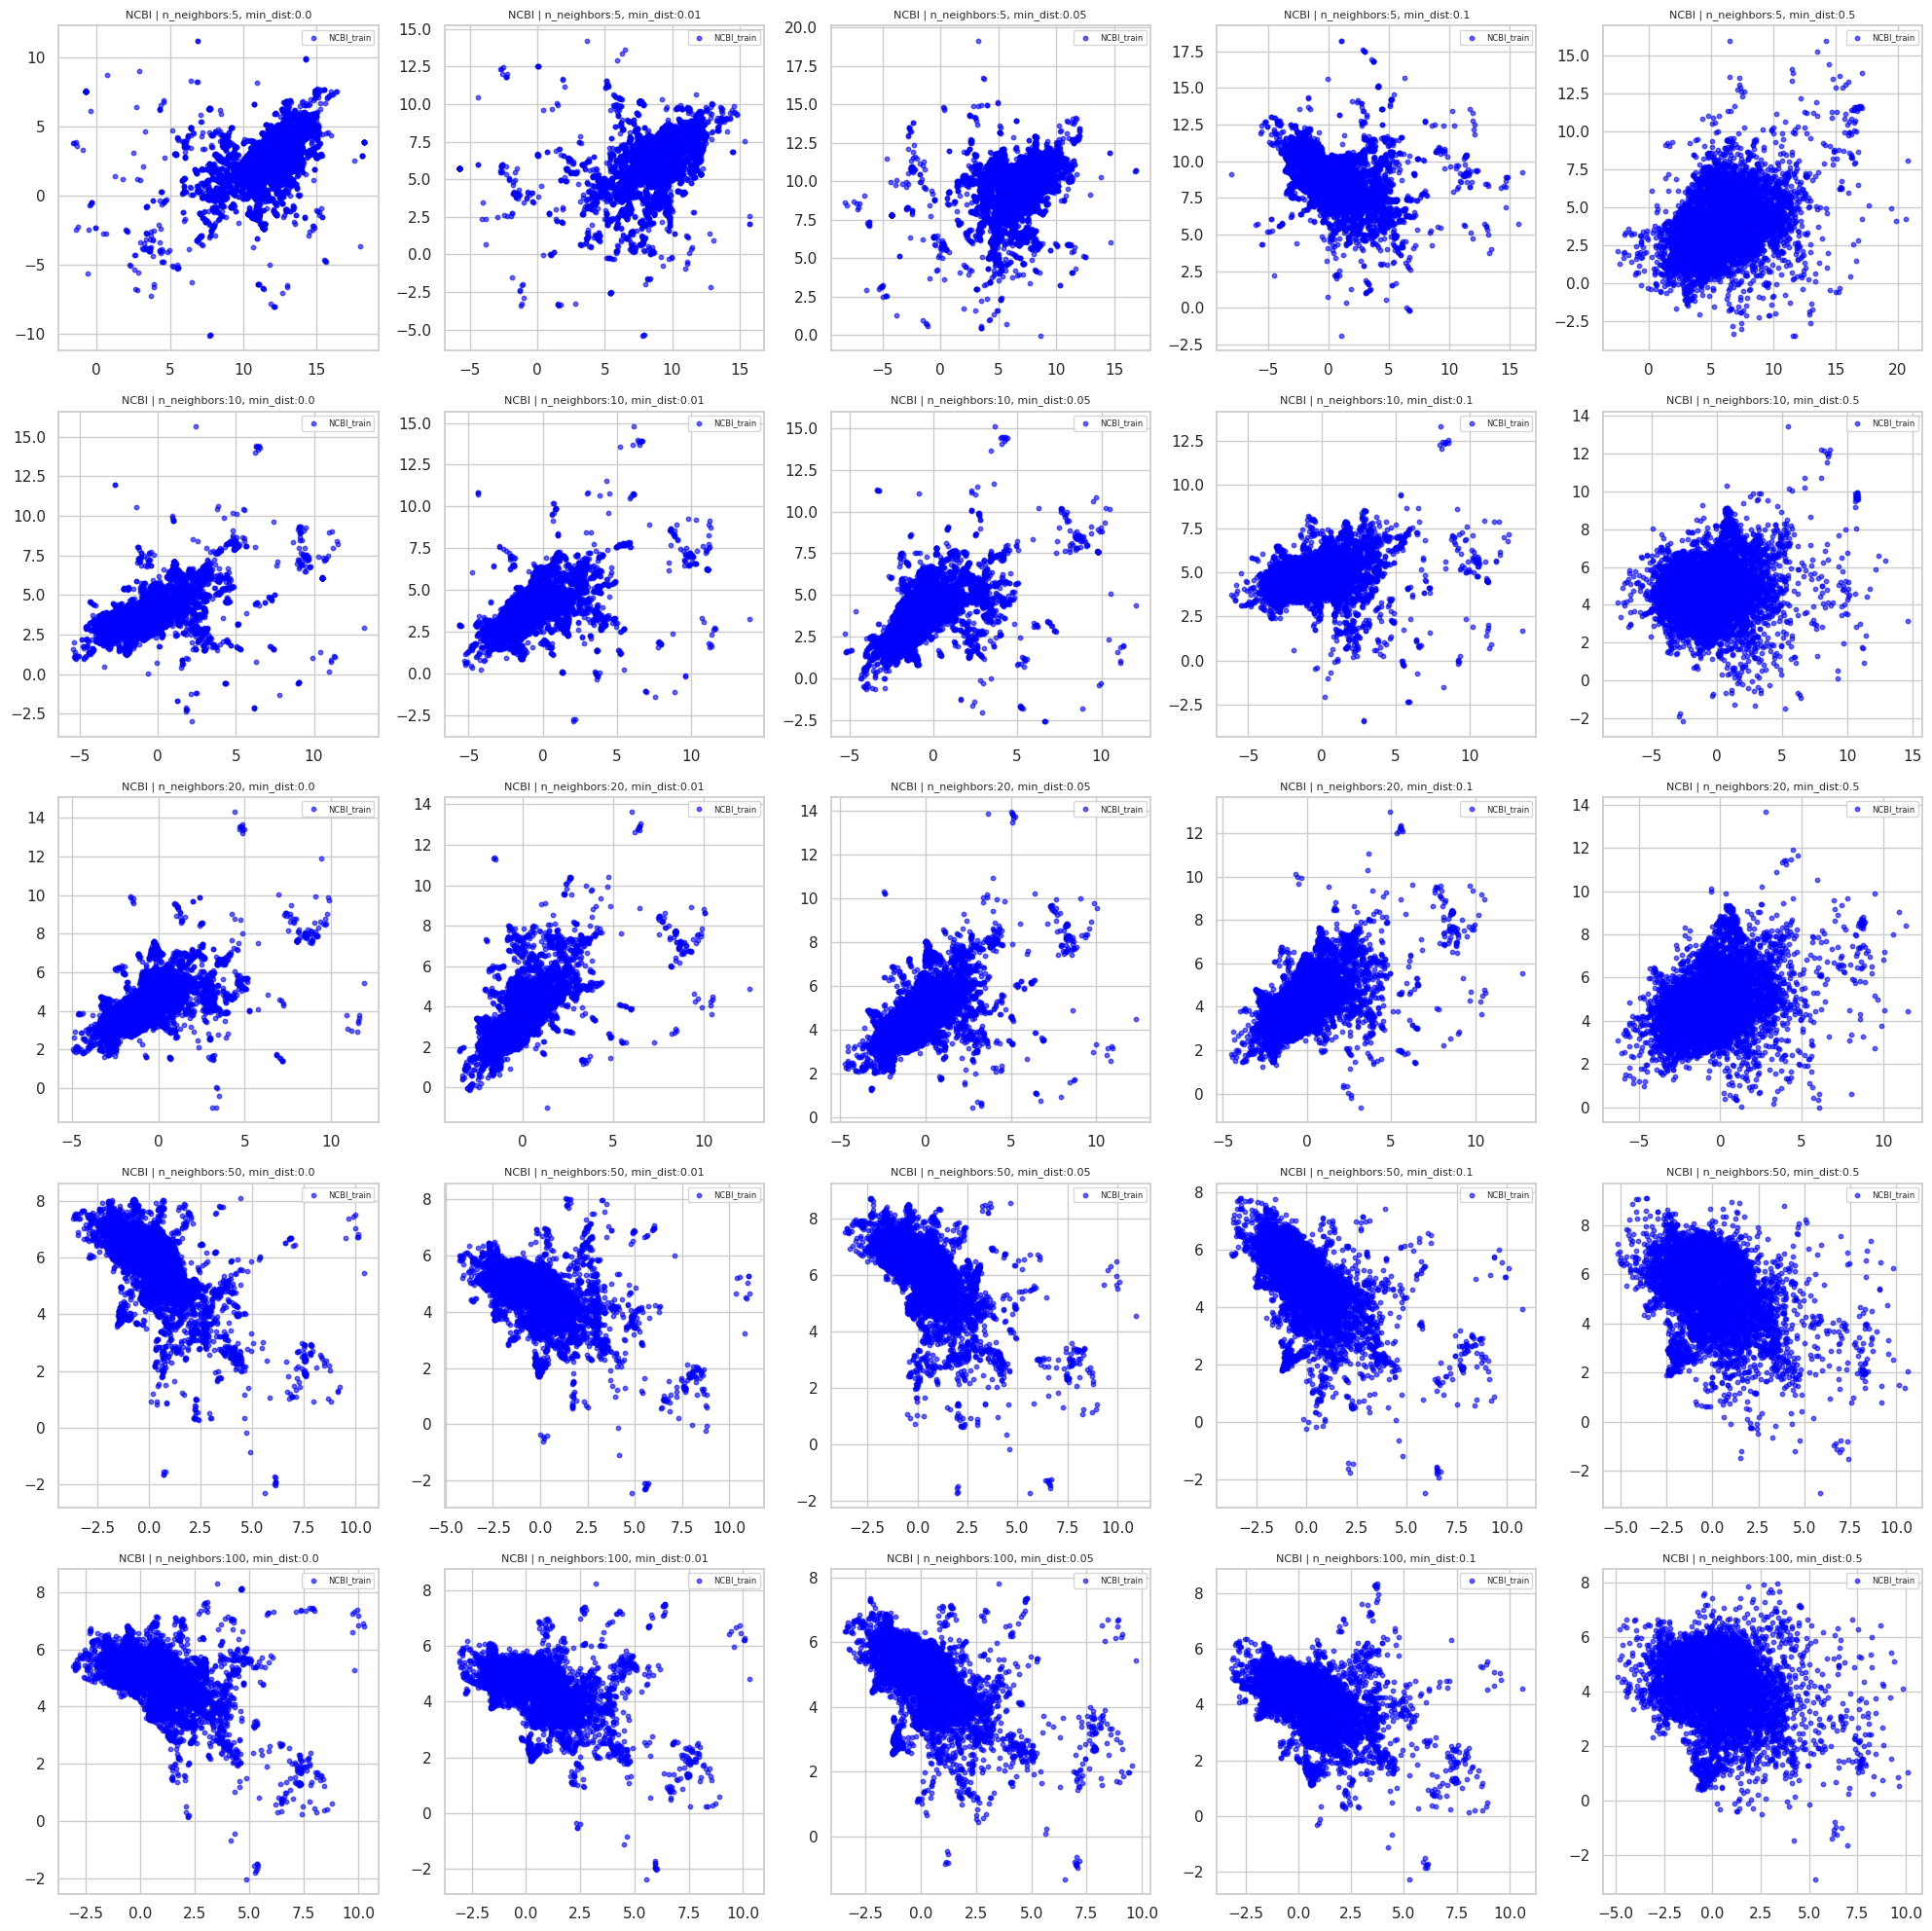

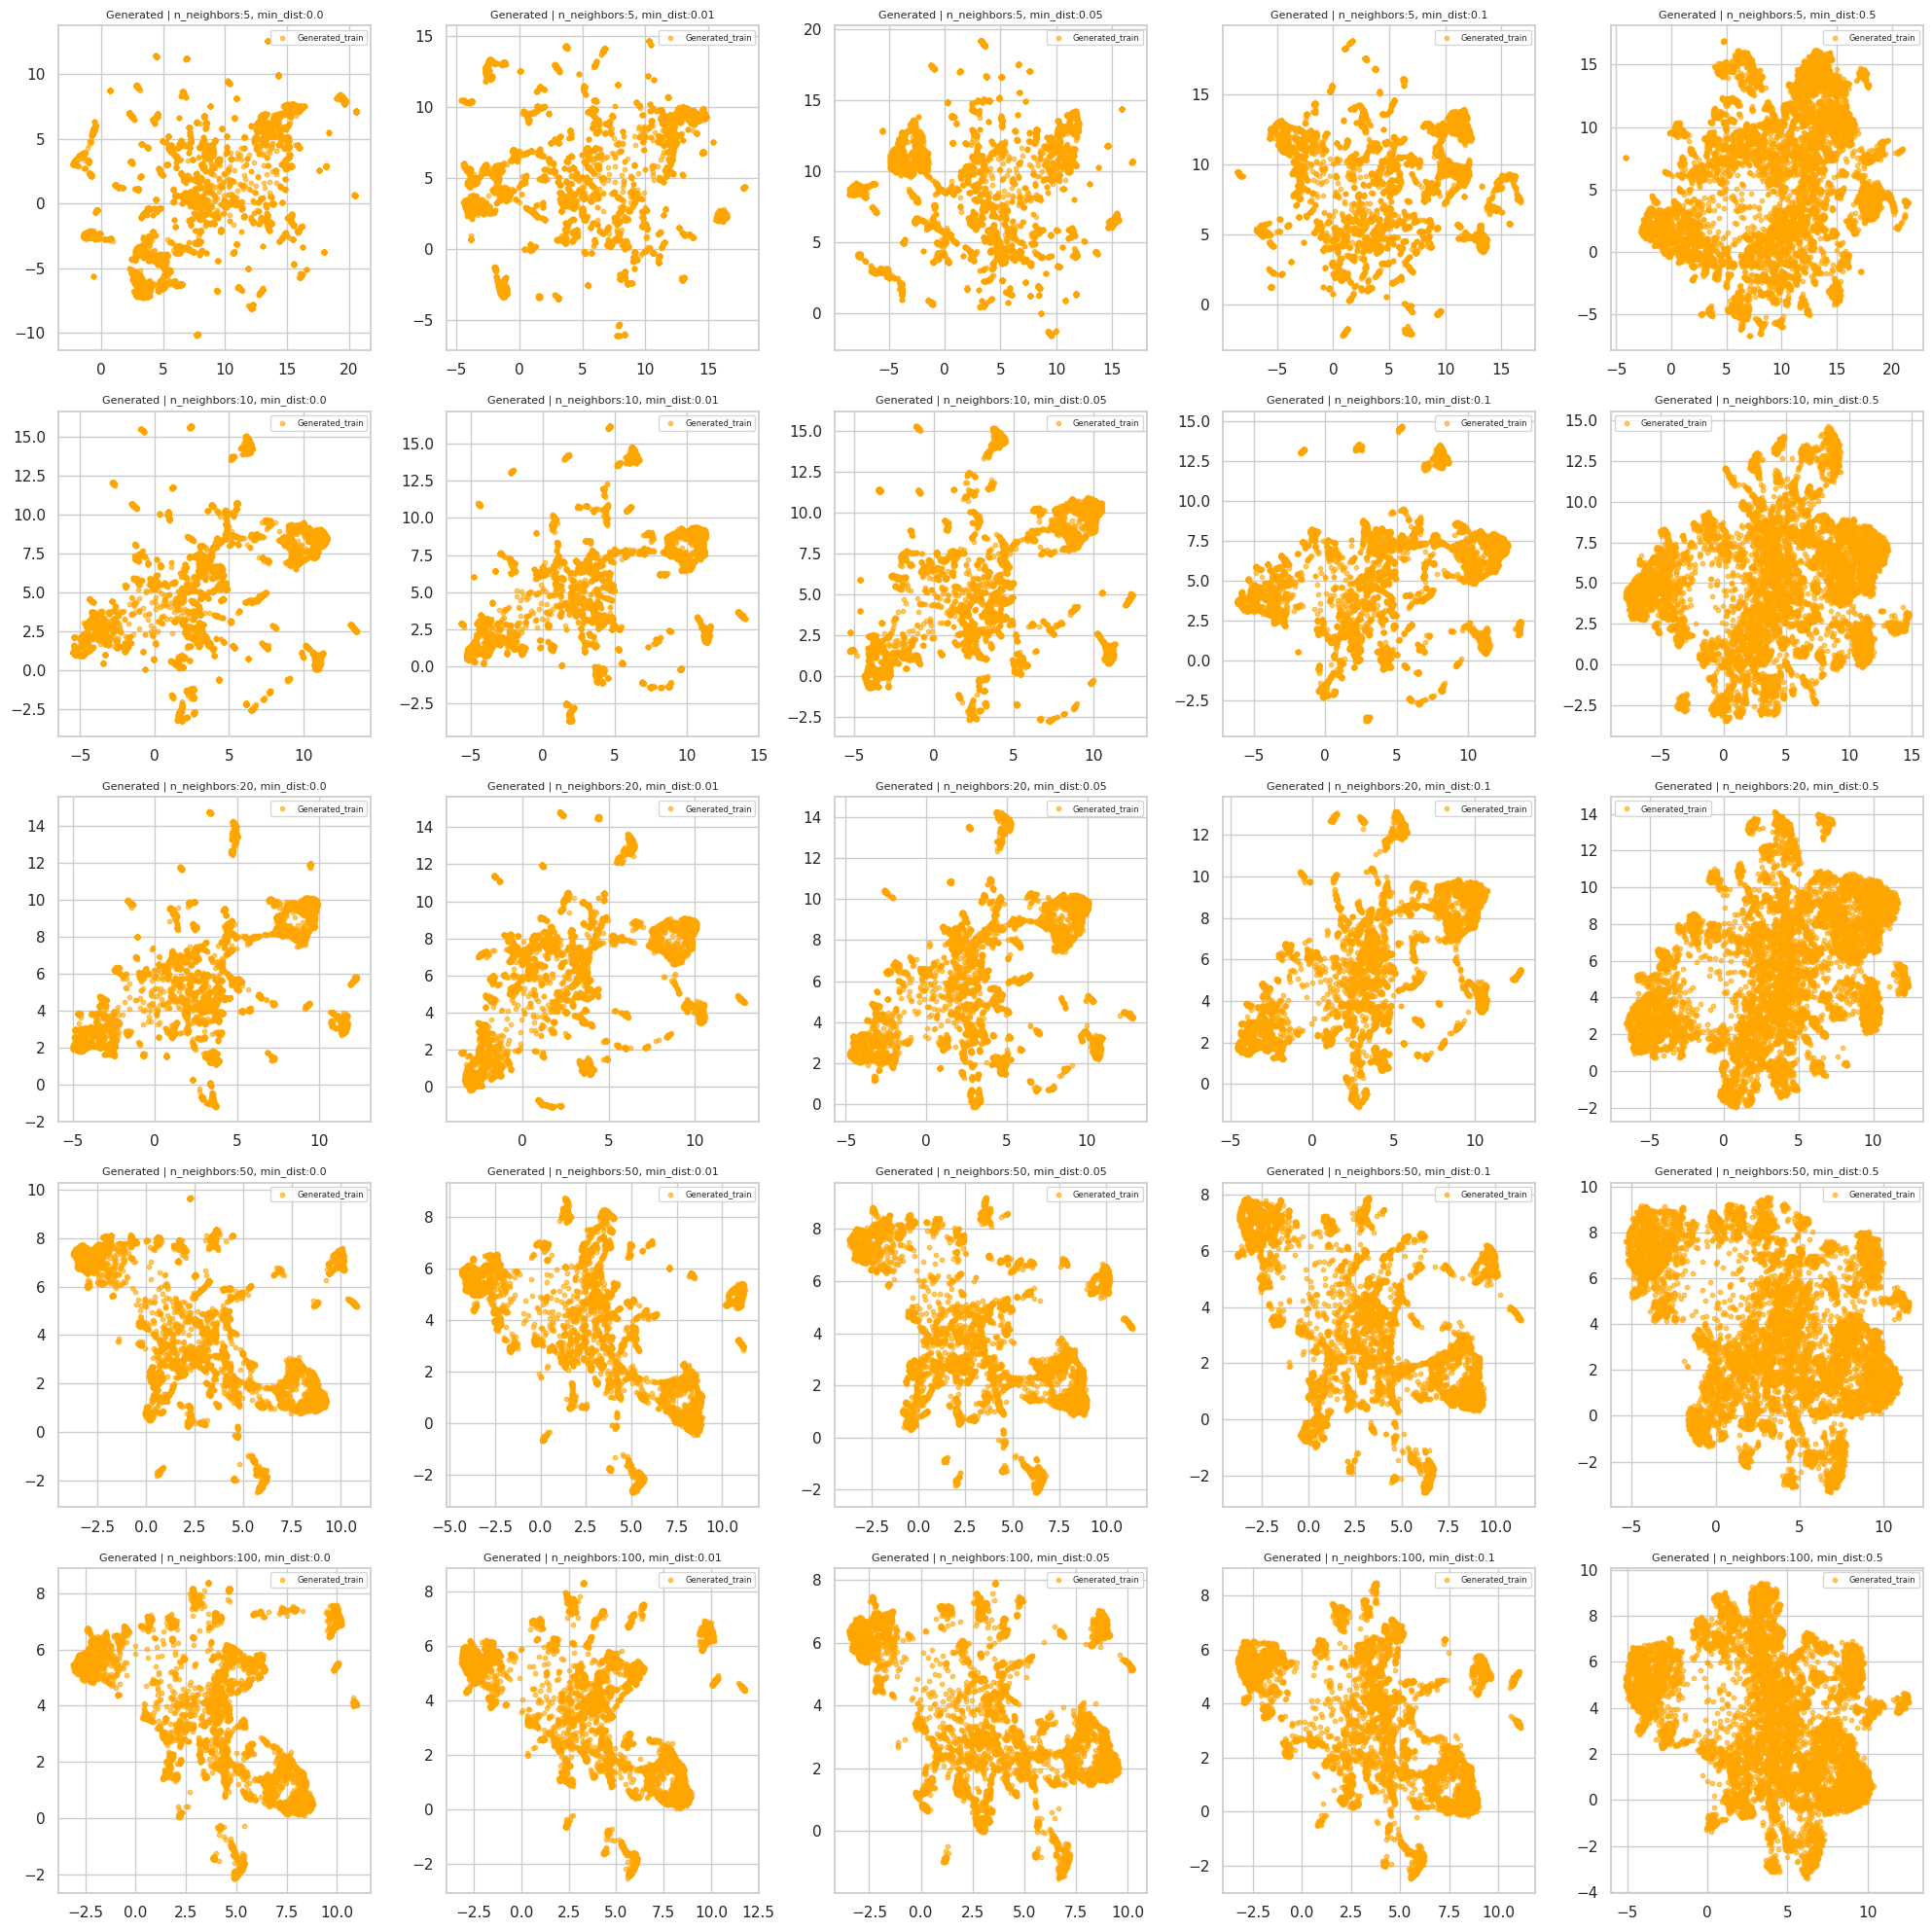

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

neighbors = [5, 10, 20, 50, 100]
min_dists = [0.0, 0.01, 0.05, 0.1, 0.5]

n_rows = len(neighbors)
n_cols = len(min_dists)

fig_all, axes_all = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
fig_ncbi, axes_ncbi = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
fig_gen, axes_gen = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

axes_all = axes_all.flatten()
axes_ncbi = axes_ncbi.flatten()
axes_gen = axes_gen.flatten()

# silhouette_results = []

# # Divide by corpus
# pos_texts_NCBI = [" ".join(d["pos"]) for d in data if d["corpus"] == "NCBI_train"]
# dep_texts_NCBI = [" ".join(d["dep"]) for d in data if d["corpus"] == "NCBI_train"]

# X_scaled_NCBI, _, _ = vectorize_and_scale(pos_texts_NCBI, dep_texts_NCBI)

# pos_texts_gen = [" ".join(d["pos"]) for d in data if d["corpus"] == "generated_train"]
# dep_texts_gen = [" ".join(d["dep"]) for d in data if d["corpus"] == "generated_train"]

# X_scaled_gen, _, _ = vectorize_and_scale(pos_texts_gen, dep_texts_gen)

# --- Iterate over grid ---
for i, n_neighbors in enumerate(neighbors):
    for j, min_dist in enumerate(min_dists):
        # Calculate the linear index for the flattened arrays
        linear_index = i * n_cols + j

        umap_model = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,        # similar to t-SNE perplexity
            min_dist=min_dist,          # controls cluster tightness
            metric="cosine",       # works well for text features
            # random_state=42,
            n_jobs=48,
        )

        umap_fit = umap_model.fit_transform(embeddings)
        # X_umap_NCBI = umap_fit.transform(embeddings)
        # X_umap_gen = umap_fit.transform(embeddings)

        df = pd.DataFrame(umap_fit, columns=["UMAP1", "UMAP2"])
        df["corpus"] = corpus

        df_ncbi = df[df["corpus"] == "NCBI_train"]
        df_gen = df[df["corpus"] == "generated_train"]

        # Select subplot axes
        ax = axes_all[linear_index]
        bx = axes_ncbi[linear_index]
        cx = axes_gen[linear_index]

        # --- Plot both datasets ---
        sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue="corpus", ax=ax, alpha=0.6, s=10)
        ax.set_title(f"Both | n_neighbors:{n_neighbors}, min_dist:{min_dist}", fontsize=8)
        ax.legend(fontsize=6)

        # --- Plot only NCBI ---
        bx.scatter(df_ncbi["UMAP1"], df_ncbi["UMAP2"], alpha=0.6, color="blue", label="NCBI_train", s=10)
        bx.set_title(f"NCBI | n_neighbors:{n_neighbors}, min_dist:{min_dist}", fontsize=8)
        bx.legend(fontsize=6)

        # --- Plot only Generated ---
        cx.scatter(df_gen["UMAP1"], df_gen["UMAP2"], alpha=0.6, color="orange", label="Generated_train", s=10)
        cx.set_title(f"Generated | n_neighbors:{n_neighbors}, min_dist:{min_dist}", fontsize=8)
        cx.legend(fontsize=6)

# Adjust spacing
for fig in [fig_all, fig_ncbi, fig_gen]:
    fig.tight_layout()

plt.show()


fig_all.savefig("umap_both_grid.png", dpi=300)
fig_ncbi.savefig("umap_ncbi_grid.png", dpi=300)
fig_gen.savefig("umap_generated_grid.png", dpi=300)

In [ ]:
def filter_clusters(df, percentage=0.95):
  filtered_clusters = []
  for cluster_id, group in df.groupby("cluster"):
      if cluster_id == -1:  # skip noise
          continue
      total = len(group)
      ncbi_count = sum(group["corpus"] == "NCBI_train")
      gen_count = sum(group["corpus"] == "generated_train")
      ncbi_ratio = ncbi_count / total
      gen_ratio = gen_count / total

      print(f"Cluster {cluster_id}:")
      print(f"NCBI: {ncbi_count} ({ncbi_ratio:.2%})")
      print(f"Generated: {gen_count} ({gen_ratio:.2%})")

      if ncbi_ratio >= percentage and gen_ratio <= 1-percentage:
          filtered_clusters.append(cluster_id)

  candidate_sentences = df[df["cluster"].isin(filtered_clusters)]
  return filtered_clusters, candidate_sentences


In [ ]:
df.shape
df.columns

Index(['UMAP1', 'UMAP2', 'corpus', 'entities', 'cluster'], dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import HDBSCAN
import matplotlib.pyplot as plt

# df["id"] = ids
# df["sentence"] = sentences
df["entities"] = [d.get("entities") for d in data]
# X_umap = df[["UMAP1", "UMAP2"]].values

db = HDBSCAN(min_samples=25,
            n_jobs=48,
            ).fit(embeddings)
df["cluster"] = db.labels_

percentage = 0.55
filtered_clusters, candidate_sentences = filter_clusters(df, percentage)

print(f"Found {len(filtered_clusters)} clusters meeting the criteria.")
print("Selected clusters:", filtered_clusters)

selected_df = df[df["cluster"].isin(filtered_clusters)]

print(f"Found {len(selected_df)} sentences in pure NCBI clusters.")

Cluster 0:
NCBI: 0 (0.00%)
Generated: 53 (100.00%)
Cluster 1:
NCBI: 1 (10.00%)
Generated: 9 (90.00%)
Cluster 2:
NCBI: 12 (31.58%)
Generated: 26 (68.42%)
Cluster 3:
NCBI: 0 (0.00%)
Generated: 88 (100.00%)
Cluster 4:
NCBI: 44 (5.90%)
Generated: 702 (94.10%)
Cluster 5:
NCBI: 1 (2.27%)
Generated: 43 (97.73%)
Cluster 6:
NCBI: 0 (0.00%)
Generated: 7 (100.00%)
Cluster 7:
NCBI: 0 (0.00%)
Generated: 40 (100.00%)
Cluster 8:
NCBI: 0 (0.00%)
Generated: 29 (100.00%)
Cluster 9:
NCBI: 0 (0.00%)
Generated: 14 (100.00%)
Cluster 10:
NCBI: 0 (0.00%)
Generated: 11 (100.00%)
Cluster 11:
NCBI: 0 (0.00%)
Generated: 42 (100.00%)
Cluster 12:
NCBI: 0 (0.00%)
Generated: 11 (100.00%)
Cluster 13:
NCBI: 84 (1.90%)
Generated: 4339 (98.10%)
Cluster 14:
NCBI: 64 (100.00%)
Generated: 0 (0.00%)
Found 1 clusters meeting the criteria.
Selected clusters: [14]
Found 64 sentences in pure NCBI clusters.


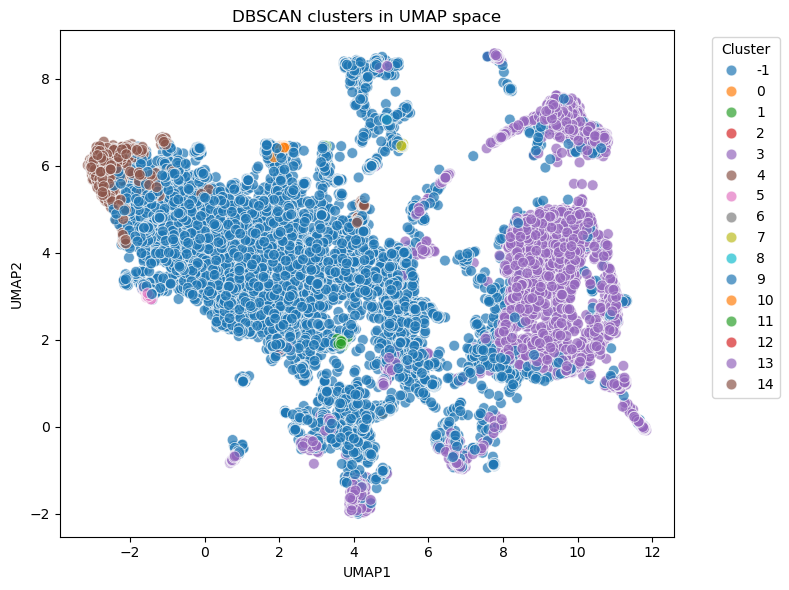

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="UMAP1", y="UMAP2",
    hue="cluster",           # use hue, not color
    palette="tab10",         # good categorical palette
    alpha=0.7,
    s=60
)

plt.title(f"DBSCAN clusters in UMAP space")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster")
plt.tight_layout()
plt.show()


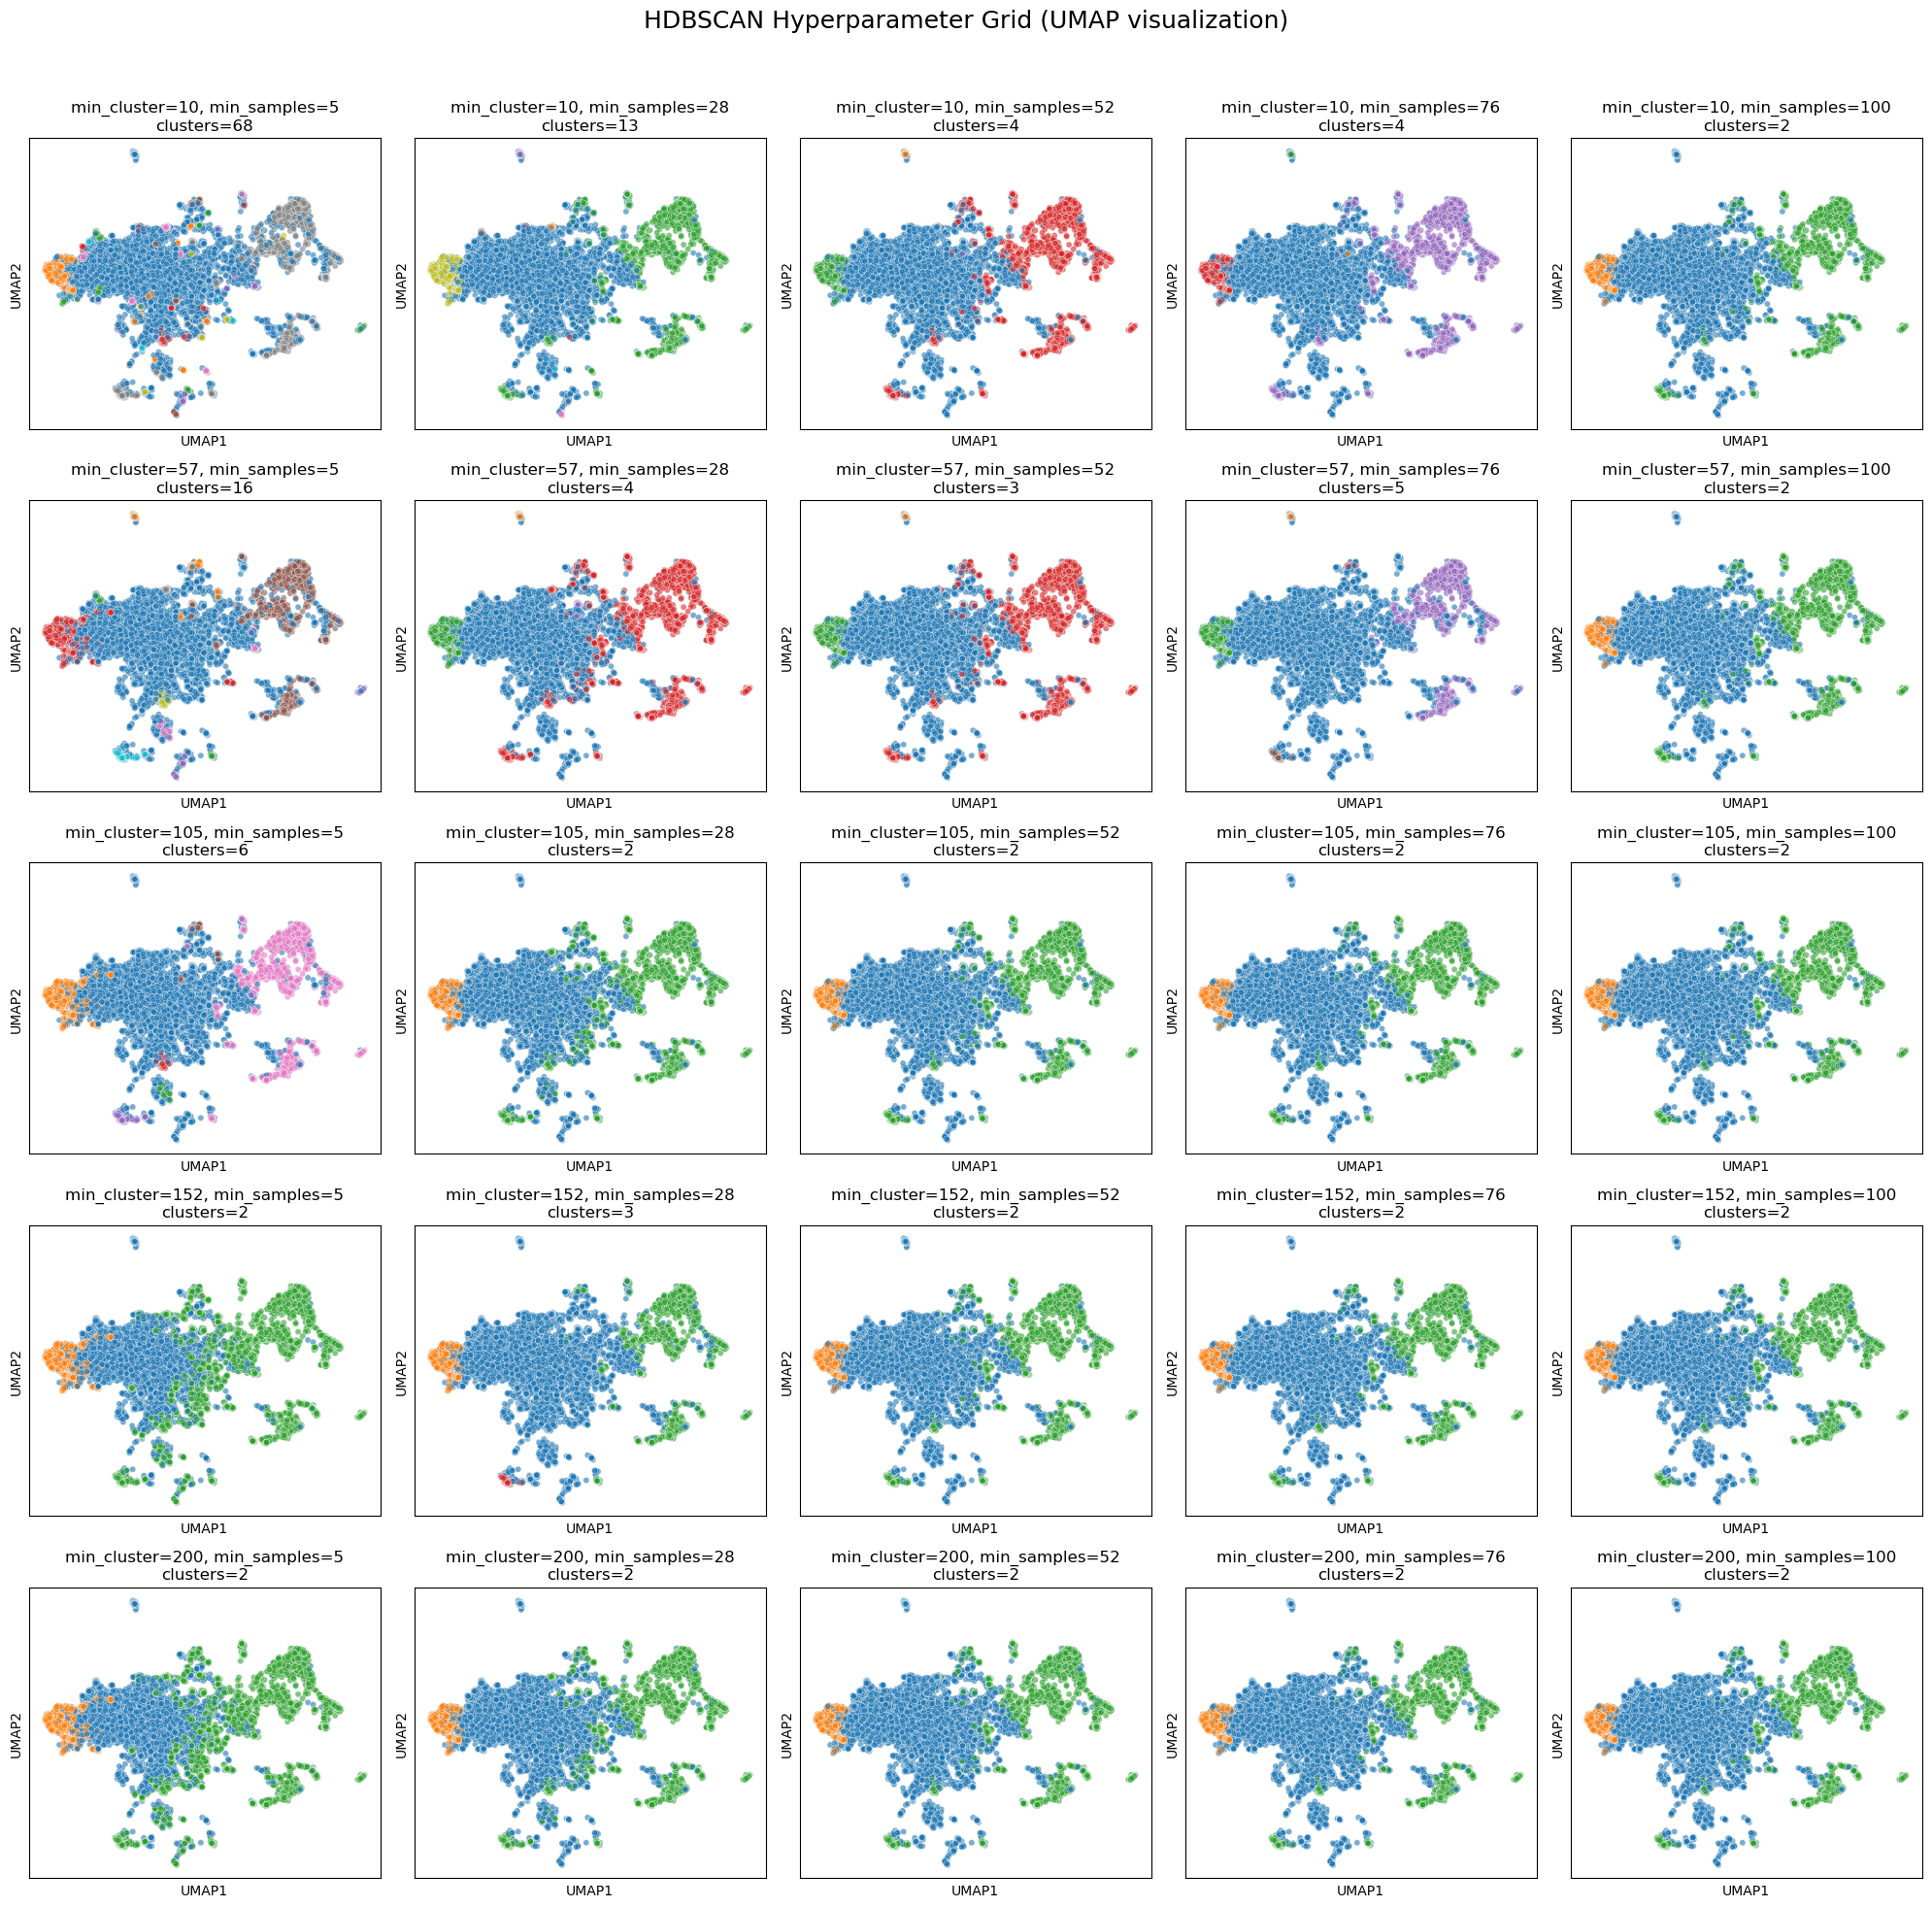

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN

# Define a 5×5 grid for HDBSCAN hyperparameters
min_cluster_sizes = np.linspace(10, 200, 5, dtype=int)
min_samples_values = np.linspace(5, 100, 5, dtype=int)

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

for i, mcs in enumerate(min_cluster_sizes):
    for j, ms in enumerate(min_samples_values):
        ax = axes[i, j]

        # Run HDBSCAN with given parameters
        clusterer = HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='eom',
            n_jobs=48
        ).fit(embeddings)

        df[f"cluster_{mcs}_{ms}"] = clusterer.labels_

        # Plot clusters in UMAP space
        sns.scatterplot(
            data=df,
            x="UMAP1", y="UMAP2",
            hue=f"cluster_{mcs}_{ms}",
            palette="tab10",
            alpha=0.6,
            s=20,
            legend=False,
            ax=ax
        )

        n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
        ax.set_title(f"min_cluster={mcs}, min_samples={ms}\nclusters={n_clusters}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("HDBSCAN Hyperparameter Grid (UMAP visualization)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
